In [1]:
from Moment import *

In [27]:
# True ground state 


N = 7
J = 1.0
g = 0.5

X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.array([[1, 0], [0, 1]], dtype=complex)

start = time.time()



H = Hamiltonian(N, J, g)

eigenval, eigenvect = np.linalg.eigh(H.full())

end = time.time()
print(f"\n \n Elapsed time: {end - start:.4f} seconds")
print("Ground State energy", eigenval[0])


 
 Elapsed time: 0.0227 seconds
Ground State energy -6.579920439429844


In [28]:

print(eigenval[1])

-6.568198110288694


In [28]:
N = 3


basis = []



basis = NPA(3, N, _, True)
print(f"Basis size: {len(basis)}")

M_expr, var_dict, _ = create_moment_matrix(basis)



symbolic_H = get_symbolic_hamiltonian(N, J, g)
objective_expr = 0

start = time.time()

print("Constructing objective...")
for coeff, term in symbolic_H:

    key = Monomial(term.op, term.site, 1.0)
    
    if key in var_dict:
        objective_expr += coeff * var_dict[key] * term.phase
    elif key.op == 'I':
        objective_expr += coeff
    else:
        print(f"Warning: Hamiltonian term {term} not covered by the moment!")




constraints = [M_expr >> 0] 



prob = cp.Problem(cp.Minimize(objective_expr), constraints)

print("Solving SDP...")
prob.solve(solver=cp.MOSEK, verbose=False) 

end = time.time()


print("-" * 50)
print("problem status = ", prob.status)
print("-" * 50)

print(f"{'SDP Ground State Energy:':<28} {prob.value}")
print(f"{'True Ground State energy:':<28} {eigenval[0]}")
print("-" * 50)

delta =  eigenval[0] - prob.value
print(f"Delta True/SDP moment: {delta}")
print(f"\n \n Elapsed time: {end - start:.4f} seconds")

Basis size: 64
Constructing objective...
Solving SDP...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------
SDP Ground State Energy:     -2.4032135508891344
True Ground State energy:    -6.579920439429844
--------------------------------------------------
Delta True/SDP moment: -4.17670688854071

 
 Elapsed time: 1.8128 seconds


Constructing objective...
Solving SDP for NPA level 1...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------
SDP Ground State Energy:     -2.4405443613127837
True Ground State energy:    -6.579920439429844
--------------------------------------------------
Delta True/SDP moment: -4.13937607811706

Elapsed time: 0.0353 seconds 
 

Constructing objective...
Solving SDP for NPA level 2...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------
SDP Ground State Energy:     -2.403205427881818
True Ground State energy:    -6.579920439429844
--------------------------------------------------
Delta True/SDP moment: -4.176715011548026

Elapsed time: 0.6114 seconds 
 

Constructing objective...
Solving SDP for NPA level 3...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------

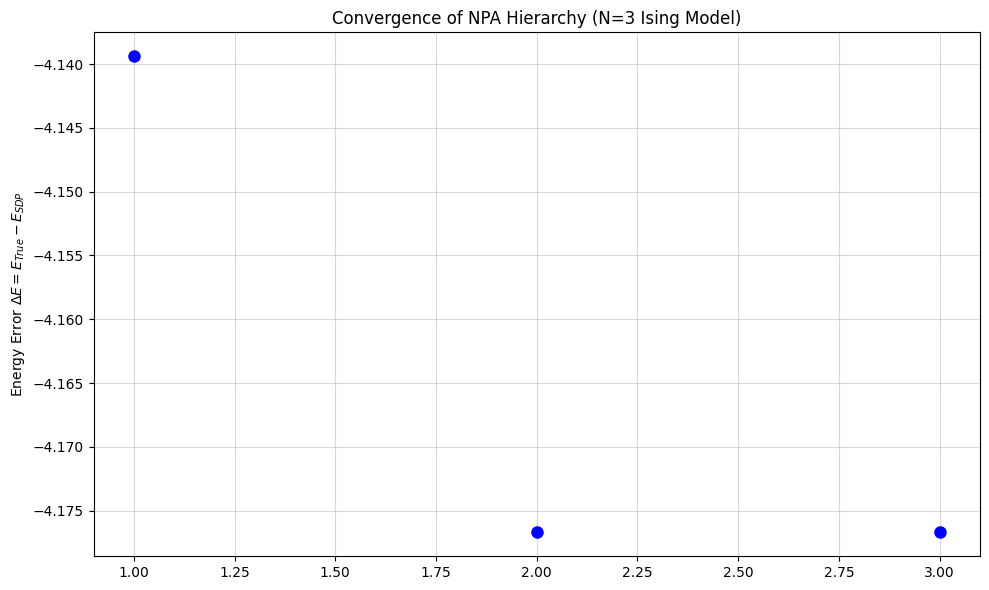

In [29]:
N = 3

levels = []
sdp_energies = []
deltas = []

for k in range(1, N + 1):
    levels.append(k)
    basis = NPA(k, N, _, True)
    # print(f"Basis size: {len(basis)}")
    
    M_expr, var_dict, _ = create_moment_matrix(basis)
    
    symbolic_H = get_symbolic_hamiltonian(N, J, g)
    objective_expr = 0
    
    start = time.time()
    
    print("Constructing objective...")
    for coeff, term in symbolic_H:
    
        key = Monomial(term.op, term.site, 1.0)
        
        if key in var_dict:
            objective_expr += coeff * var_dict[key] * term.phase
        elif key.op == 'I':
            objective_expr += coeff
        else:
            print(f"Warning: Hamiltonian term {term} not covered by the moment!")
    
    
    constraints = [M_expr >> 0] 
    
    
    prob = cp.Problem(cp.Minimize(objective_expr), constraints)
    
    print(f"Solving SDP for NPA level {k}...")
    prob.solve(solver=cp.MOSEK, verbose=False) 
    
    end = time.time()
    
    sdp_energies.append(prob.value)
    print("-" * 50)
    print("problem status = ", prob.status)
    print("-" * 50)
    
    print(f"{'SDP Ground State Energy:':<28} {prob.value}")
    print(f"{'True Ground State energy:':<28} {eigenval[0]}")
    print("-" * 50)
    
    delta =  eigenval[0] - prob.value
    deltas.append(delta)
    print(f"Delta True/SDP moment: {delta}\n")
    print(f"Elapsed time: {end - start:.4f} seconds \n \n")


plt.figure(figsize=(10, 6))

# Plot 1: Energy Delta (Log Scale)

plt.plot(levels, deltas, 'bo', linewidth=2, markersize=8)
# plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.ylabel(r"Energy Error $\Delta E = E_{True} - E_{SDP}$")
plt.title(f"Convergence of NPA Hierarchy (N={N} Ising Model)")



plt.tight_layout()
plt.show()

In [30]:
# N = 5


basis = []
eps = 0.01


basis = NPA(N, N, _, True)
print(f"Basis size: {len(basis)}")

M_expr, var_dict, _ = create_moment_matrix(basis)



symbolic_H = get_symbolic_hamiltonian(N, J, g)
objective_expr = 0

start = time.time()

print("Constructing objective...")
for coeff, term in symbolic_H:

    key = Monomial(term.op, term.site, 1.0)
    
    if key in var_dict:
        objective_expr += coeff * var_dict[key] * term.phase
    elif key.op == 'I':
        objective_expr += coeff
    else:
        print(f"Warning: Hamiltonian term {term} not covered by the moment!")

init = -1.8322494179824158

E_max = init + 2* eps
E_min = init + eps

print(f"Window : {E_min} <-> {E_max}")
constraints = [M_expr >> 0] 
constraints.append( objective_expr <= E_max) 
constraints.append( objective_expr >= E_min) 


prob = cp.Problem(cp.Minimize(objective_expr), constraints)

print("Solving SDP...")
prob.solve(solver=cp.MOSEK, verbose=False) 

end = time.time()


print("-" * 50)
print("problem status = ", prob.status)
print("-" * 50)

print(f"{'SDP Energy:':<28} {prob.value}")
print(f"{'True energy:':<28} {eigenval[2]}")
print("-" * 50)

delta =  eigenval[2] - prob.value
print(f"Delta True/SDP moment: {delta}")
print(f"\n \n Elapsed time: {end - start:.4f} seconds")

Basis size: 64
Constructing objective...
Window : -1.8222494179824158 <-> -1.8122494179824158
Solving SDP...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------
SDP Energy:                  -1.8222494179148552
True energy:                 -5.3539039757286915
--------------------------------------------------
Delta True/SDP moment: -3.5316545578138365

 
 Elapsed time: 1.9936 seconds


In [35]:
N = 13
J = 1.0
g = 0.5

X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.array([[1, 0], [0, 1]], dtype=complex)

start = time.time()



H = Hamiltonian(N, J, g)

eigenval, eigenvect = np.linalg.eigh(H.full())

end = time.time()
print(f"\n \n Elapsed time: {end - start:.4f} seconds")
print("Ground State energy", eigenval[0])


 
 Elapsed time: 0.0187 seconds
Ground State energy -6.579920439429844


In [36]:
basis = NPA(1, N, _, True) # order 2, N particles
print(f"Basis size: {len(basis)}")

Basis size: 22


In [38]:
# Open the shell



eps = 0.001
var_dict = {}

# shell
E_target = eigenval[1]
E_min = E_target - eps
E_max = E_target + eps

# compute moments

print("Computing moment matrices...")

M_expr, var_dict, _ = create_moment_matrix(basis)
symbolic_H = get_symbolic_hamiltonian(N, J, g)
M_H, var_dict, _ = create_localizing_matrix(basis, symbolic_H, var_dict)

#  Objective Function

print("Computing objective function...")
objective_expr = create_objective_function(symbolic_H, var_dict)

# Constraints
print(f"Imposing Window: [{E_min:.4f}; {E_max:.4f}]")

#  Commutator constraint
A_op = Monomial("X", [(1, 0, 0)])

comm_constraint_expr = create_commutator_constraint(A_op, symbolic_H, var_dict)


constraints = [M_expr >> 0]
# constraints.append(M_expr[0, 0] == 1.0)       # Normalization


constraints.append(M_H - E_min * M_expr >> 0) 
constraints.append(-M_H + E_max * M_expr >> 0)
constraints.append(comm_constraint_expr == 0)


print("Solving SDP...")
prob = cp.Problem(cp.Minimize(objective_expr), constraints)
start = time.time()
prob.solve(solver=cp.MOSEK, verbose=False) 
end = time.time()

# Results
print("-" * 50)
print("problem status = ", prob.status)
print("-" * 50)
if prob.value is not None:
    print(f"{'SDP Energy:':<28} {prob.value:.6f}")
    print(f"{'True energy:':<28} {E_target:.6f}")
    delta = E_target - prob.value
    print(f"Delta True/SDP: {delta:.6e}")
else:
    print("Solver failed to return a value.")

print(f"Elapsed time: {end - start:.4f} seconds")

Computing moment matrices...
Computing objective function...
Imposing Window: [-6.5692; -6.5672]
Solving SDP...
--------------------------------------------------
problem status =  optimal
--------------------------------------------------
SDP Energy:                  -6.569175
True energy:                 -6.568198
Delta True/SDP: 9.765425e-04
Elapsed time: 20.0900 seconds


In [ ]:
basis = NPA(1, N, _, True) # order 2, N particles
print(f"Basis size: {len(basis)}")

Computing exact diagonalization for N = 4 particles
Computing SDP for N = 4 particles with eps = 0.1
Computing exact diagonalization for N = 5 particles
Computing SDP for N = 5 particles with eps = 0.1
Computing exact diagonalization for N = 6 particles
Computing SDP for N = 6 particles with eps = 0.1
Computing exact diagonalization for N = 7 particles
Computing SDP for N = 7 particles with eps = 0.1
Computing exact diagonalization for N = 8 particles
Computing SDP for N = 8 particles with eps = 0.1
Computing exact diagonalization for N = 9 particles
Computing SDP for N = 9 particles with eps = 0.1
Computing exact diagonalization for N = 10 particles
Computing SDP for N = 10 particles with eps = 0.1
Computing exact diagonalization for N = 11 particles
Computing SDP for N = 11 particles with eps = 0.1
Computing exact diagonalization for N = 12 particles
Computing SDP for N = 12 particles with eps = 0.1
Computing exact diagonalization for N = 13 particles
Computing SDP for N = 13 particl

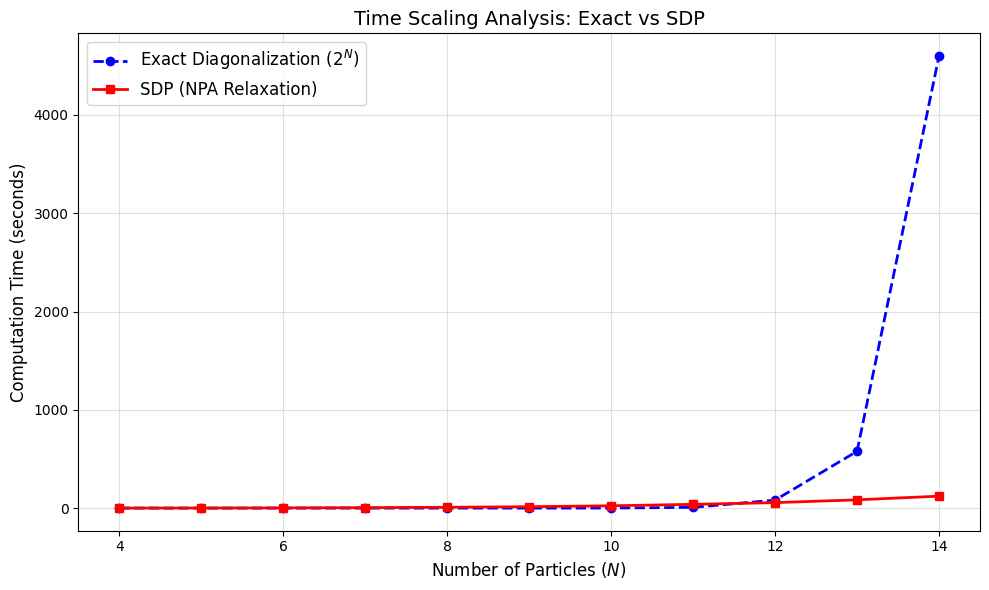

In [65]:
# time scale comparison

Ns = [4,5,6,7,8,9,10,11,12,13,14] # 
J = 1.0
g = 0.5

eps = 0.1
var_dict = {}

X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.array([[1, 0], [0, 1]], dtype=complex)

exact_times = []
sdp_times = []
deltas = []


for n in Ns:
    H = Hamiltonian(n, J, g)
    print(f"Computing exact diagonalization for N = {n} particles")
    start = time.time()
    eigenval, eigenvect = np.linalg.eigh(H.full())
    end = time.time()
    exact_times.append(end - start)
    # print(end - start)

# shell
    E_target = eigenval[1]
    E_min = E_target - eps
    E_max = E_target + eps

# compute moments

    print(f"Computing SDP for N = {n} particles with eps = {eps}")
    basis = NPA(1, n, _, True)
    M_expr, var_dict, _ = create_moment_matrix(basis)
    symbolic_H = get_symbolic_hamiltonian(n, J, g)
    M_H, var_dict, _ = create_localizing_matrix(basis, symbolic_H, var_dict)

#  Objective Function

    # print("Computing objective function...")
    objective_expr = create_objective_function(symbolic_H, var_dict)

# Constraints
# print(f"Imposing Window: [{E_min:.4f}; {E_max:.4f}]")

#  Commutator constraint
    A_op = Monomial("X", [(1, 0, 0)])
    
    comm_constraint_expr = create_commutator_constraint(A_op, symbolic_H, var_dict)


    constraints = [M_expr >> 0]
# constraints.append(M_expr[0, 0] == 1.0)       # Normalization


    constraints.append(M_H - E_min * M_expr >> 0) 
    constraints.append(-M_H + E_max * M_expr >> 0)
    constraints.append(comm_constraint_expr == 0)


    # print("Solving SDP...")
    prob = cp.Problem(cp.Minimize(objective_expr), constraints)
    start = time.time()
    prob.solve(solver=cp.MOSEK, verbose=False) 
    end = time.time()
    sdp_times.append(end - start)
    deltas.append(E_target - prob.value)
    # print(end - start)
# Results

plt.figure(figsize=(10, 6))

# Plot Exact Diagonalization
plt.plot(Ns, exact_times, 'o--', color='blue', label='Exact Diagonalization ($2^N$)', linewidth=2)

# Plot SDP
plt.plot(Ns, sdp_times, 's-', color='red', label='SDP (NPA Relaxation)', linewidth=2)

# Styling
# plt.yscale('log')  # Log scale is crucial for comparing exponential vs polynomial
plt.xlabel('Number of Particles ($N$)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.title('Time Scaling Analysis: Exact vs SDP', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend(fontsize=12)

# Optional: Add annotations for specific data points if they cross
# plt.annotate('Crossover', xy=(..., ...), ...)

plt.tight_layout()
plt.show()

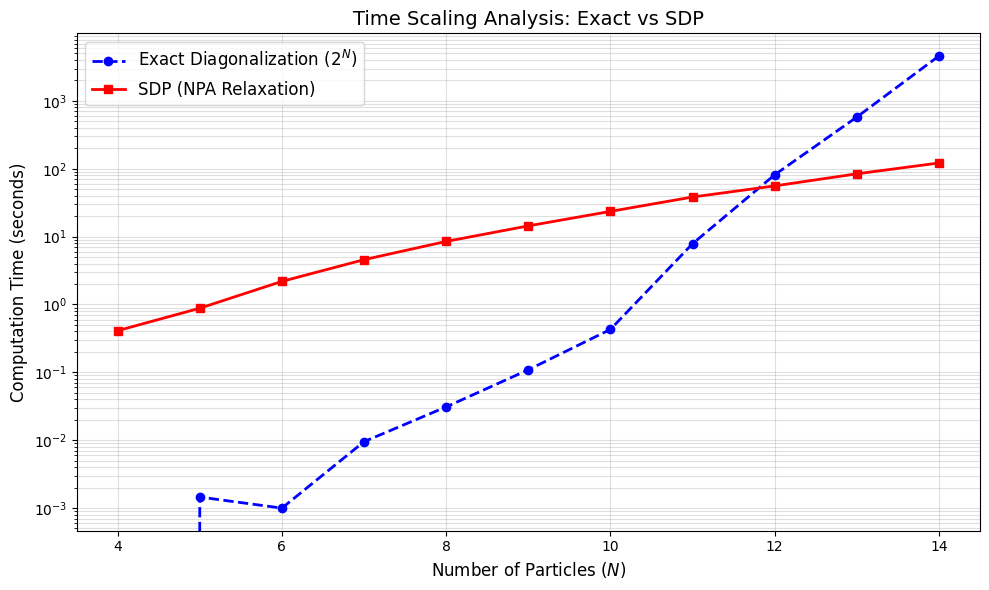

In [67]:
plt.figure(figsize=(10, 6))

# Plot Exact Diagonalization
plt.plot(Ns, exact_times, 'o--', color='blue', label='Exact Diagonalization ($2^N$)', linewidth=2)

# Plot SDP
plt.plot(Ns, sdp_times, 's-', color='red', label='SDP (NPA Relaxation)', linewidth=2)

# Styling
plt.yscale('log')  # Log scale is crucial for comparing exponential vs polynomial
plt.xlabel('Number of Particles ($N$)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.title('Time Scaling Analysis: Exact vs SDP', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend(fontsize=12)

# Optional: Add annotations for specific data points if they cross
# plt.annotate('Crossover', xy=(..., ...), ...)

plt.tight_layout()
plt.show()

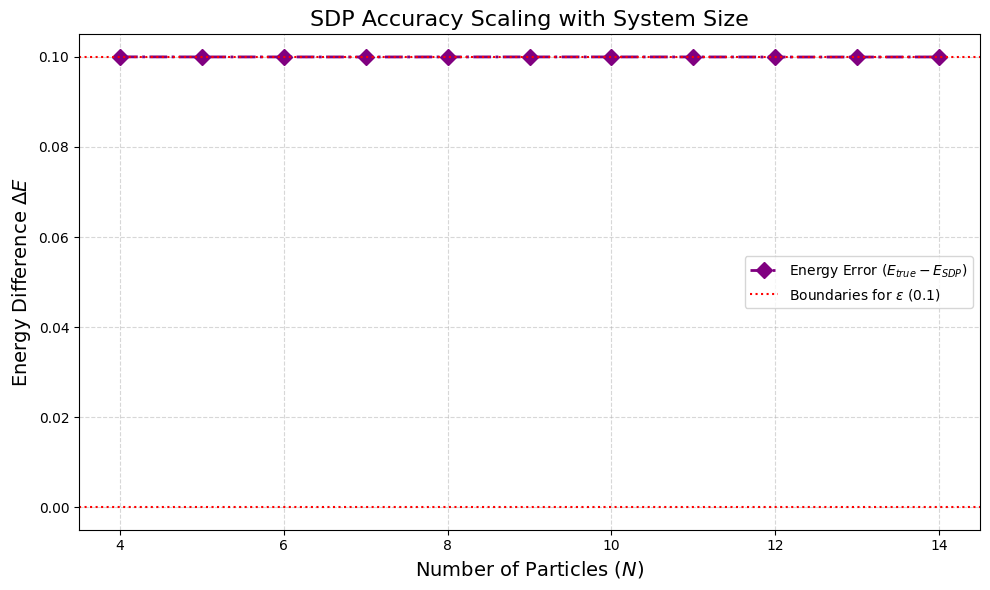

In [68]:
plt.figure(figsize=(10, 6))


plt.plot(Ns, deltas, 'D-.', color='purple', linewidth=2, markersize=8, label='Energy Error ($E_{true} - E_{SDP}$)')

plt.xlabel('Number of Particles ($N$)', fontsize=14)
plt.ylabel('Energy Difference $\Delta E$', fontsize=14)
plt.title('SDP Accuracy Scaling with System Size', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)


plt.axhline(y=eps, color='red', linestyle=':', label=f'Boundaries for $\epsilon$ ({eps})')
plt.axhline(y=0, color='red', linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
# Pauli matrices



N = 5
energy=2.2221750775147853
J = 1
g = 0.3
rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
H=build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)
basis = NPA(1, N, _, True)
eps = 0.1


In [40]:
#eigenvals for N = 5, J = 1 and g=0.3
# -4.1608741942551974
# -4.156451477774213
# -2.5834062536446627
# -2.5789835371636785
# -2.2221750775147777
# -2.217752361033793
# -1.8774679406105348
# -1.8730452241295494
# -1.6431218332214057
# -1.6386991167404212
# -0.6447071369042423
# -0.6402844204232576
# -0.2999999999999998
# -0.29557728351901513
# -0.06565389261087119
# -0.06123117612988632
# 0.06123117612988773
# 0.06565389261087276
# 0.2955772835190148
# 0.2999999999999999
# 0.6402844204232575
# 0.6447071369042425
# 1.6386991167404223
# 1.643121833221406
# 1.8730452241295494
# 1.8774679406105343
# 2.217752361033792
# 2.222175077514778
# 2.5789835371636785
# 2.5834062536446623
# 4.15645147777421
# 4.160874194255195

problem status =  optimal
problem status =  optimal
***this is the value attained on the eigenstate, exact problem***
Computing moment matrices...
Computing objective function...
Imposing Window: [-4.2609; -4.0609]
441
gasit
Solving SDP min...
problem status =  optimal
Solving SDP max...
problem status =  optimal
The min value density/moment -0.17046127273644088 -0.23991607239697638
The max value density/moment 0.3774196007410209 0.44017673369148846
Delta min bound: -0.0694548
Delta max bound: 0.0627571
Density matrix bound width: 5.478809e-01
Moment bound width: 6.800928e-01


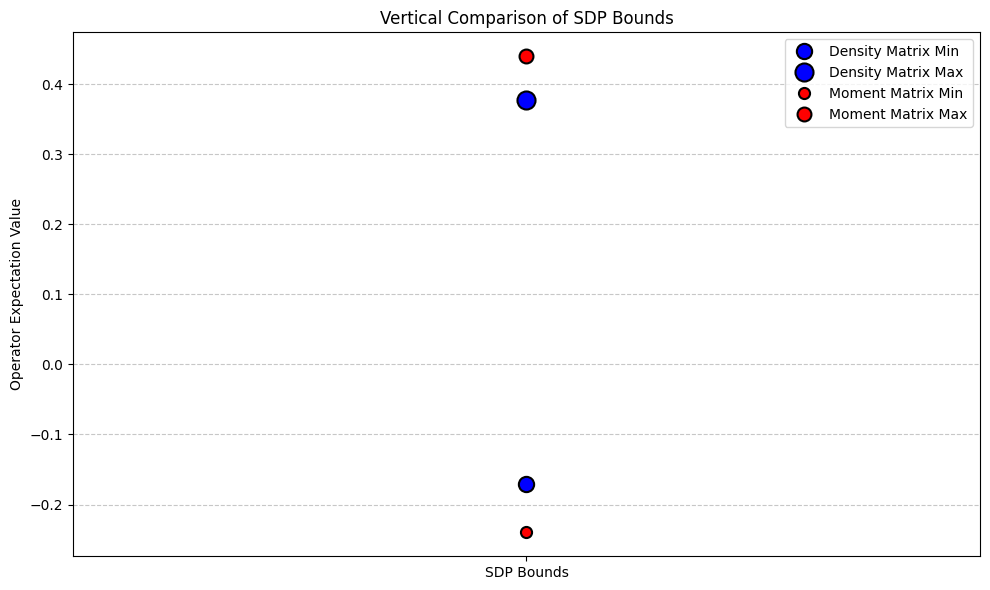

In [9]:
# Pauli matrices


N = 5
energy=-4.1608741942551974 #gs
# energy=0.2999999999999998 #some excited state
J = 1
g = 0.3
rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
H=build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)
basis = NPA(1, N, _, True)
eps = 0.1


#comparison

# SDP density matrix



#define sdp viariables
X = cp.Variable((2**N, 2**N), hermitian=True)  #the quantum state
#define constriants for the quantum state
constraints = []
constraints += [X >> 0]
constraints += [cp.trace(X) == 1]
# constraints += [X@H == (energy)*X]
constraints += [X@H >> (energy-eps)*X]
constraints += [(energy+eps)*X >> X@H ]



#defining the objective operator. a random local operator on the cenral spin.

ops_obj = [id2] * N
ops_obj[N//2] = rand_op1
obj_op=kron_n(ops_obj)



#define the problem
objective=cp.Minimize(cp.real(cp.trace(obj_op@X)))
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOSEK, verbose=False)#set verbose to true to see details on the calculation
print("problem status = ",prob.status)
min_sdp_density_mat=prob.value
# print("The min value is", min_sdp_density_mat)


#define the problem
objective=cp.Maximize(cp.real(cp.trace(obj_op@X)))
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOSEK, verbose=False)#set verbose to true to see details on the calculation
print("problem status = ",prob.status)
max_sdp_density_mat=prob.value
# print("The max value is", max_sdp_density_mat)


print("***this is the value attained on the eigenstate, exact problem***")


var_dict = {}

# shell
E_target = energy
E_min = E_target - eps
E_max = E_target + eps


# compute moments

print("Computing moment matrices...")

M_expr, var_dict, _ = create_moment_matrix(basis)
symbolic_H = get_symbolic_hamiltonian(N, J, g)
M_H, var_dict, _ = create_localizing_matrix(basis, symbolic_H, var_dict)

#  Objective Function

print("Computing objective function...")
objective_expr = create_objective_function(symbolic_op, var_dict)

# Constraints
print(f"Imposing Window: [{E_min:.4f}; {E_max:.4f}]")

#  Commutator constraint
A_op = Monomial("X", [(1, 0, 0)])
A_ops_list = [op for op in var_dict.keys() if op.op != 'I']
# print(A_ops_list)
L_ops = len(A_ops_list)
print(len(A_ops_list[:L_ops]))
comm_constraint_expr = create_commutator_constraint(A_ops_list, symbolic_H, var_dict)


constraints = [M_expr >> 0]


constraints.append(M_expr[0, 0] == 1.0)       # Normalization


constraints.append(M_H - E_min * M_expr >> 0) 
constraints.append(-M_H + E_max * M_expr >> 0)
if isinstance(comm_constraint_expr, list):
    for expr in comm_constraint_expr:
        # Append each constraint individually
        constraints.append(expr == 0)
else:
    # Single operator case
    constraints.append(comm_constraint_expr == 0)

id_key = None
for key in var_dict.keys():
    if key.op == 'I':
        id_key = key
        break

if id_key is not None:
    print("gasit")
    constraints.append(var_dict[id_key] == 1.0)


print("Solving SDP min...")
min_sdp_moment = cp.Problem(cp.Minimize(objective_expr), constraints)
# start = time.time()
min_sdp_moment.solve(solver=cp.MOSEK, verbose=False) 
# end = time.time()
print("problem status = ",min_sdp_moment.status)
# min_sdp_moment=prob.value


print("Solving SDP max...")
max_sdp_moment = cp.Problem(cp.Maximize(objective_expr), constraints)
# start = time.time()
max_sdp_moment.solve(solver=cp.MOSEK, verbose=False) 
# end = time.time()
print("problem status = ",max_sdp_moment.status)
# max_sdp_moment=prob.value



print("The min value density/moment",min_sdp_density_mat, min_sdp_moment.value)
print("The max value density/moment",max_sdp_density_mat, max_sdp_moment.value)
# print("The max value is", max_sdp_moment)

min_delta =  min_sdp_moment.value - min_sdp_density_mat
max_delta = max_sdp_moment.value - max_sdp_density_mat

print(f"Delta min bound: {min_delta:.6}")
print(f"Delta max bound: {max_delta:.6}")

print(f"Density matrix bound width: {max_sdp_density_mat - min_sdp_density_mat:.6e}")
print(f"Moment bound width: {max_sdp_moment.value - min_sdp_moment.value:.6e}")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(1, min_sdp_density_mat, 'bo', markersize=11, label='Density Matrix Min', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(1, max_sdp_density_mat, 'bo', markersize=13, label='Density Matrix Max', markeredgecolor='black', markeredgewidth=1.5)

ax.plot(1, min_sdp_moment.value, 'ro', markersize=8, label='Moment Matrix Min', markeredgecolor='black', markeredgewidth=1.5,)
ax.plot(1, max_sdp_moment.value, 'ro', markersize=10, label='Moment Matrix Max', markeredgecolor='black', markeredgewidth=1.5,)

ax.set_xticks([1])
ax.set_xticklabels(['SDP Bounds'])
ax.set_ylabel('Operator Expectation Value')
ax.set_title('Vertical Comparison of SDP Bounds')
ax.legend(loc='best')
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



In [7]:
from Moment import *
N = 5

J = 1
g = 0.3
rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
H=build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)
basis = NPA(1, N, _, True)
eps = 0.1

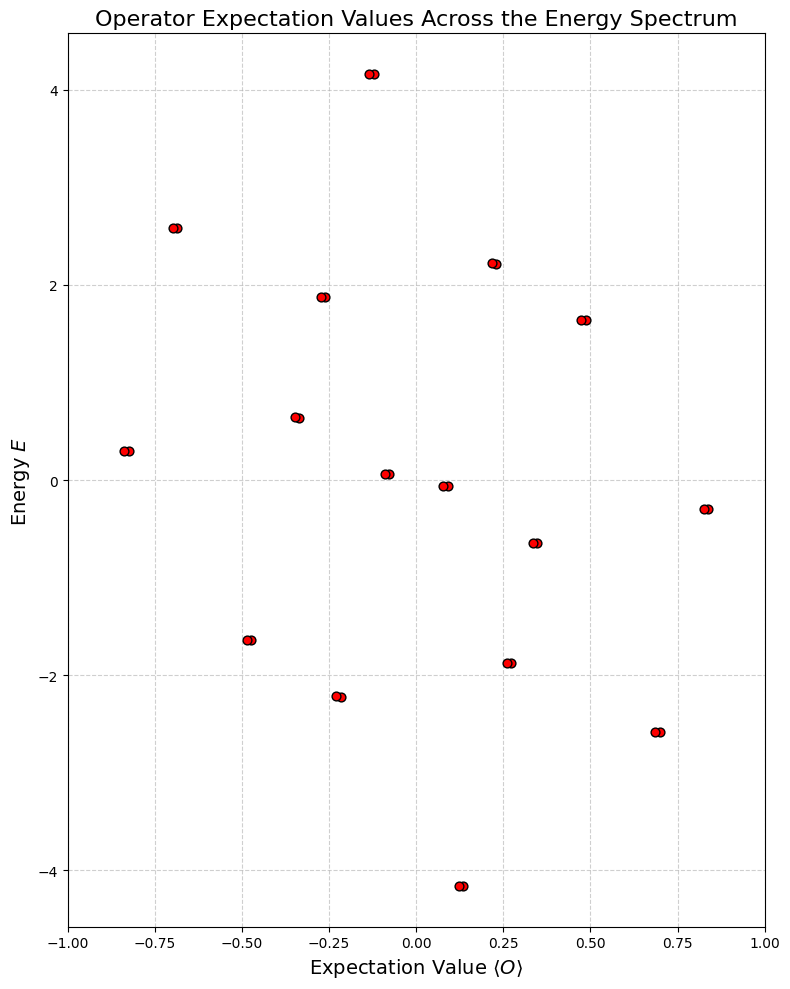

In [8]:
# exact diagonalization

eigenvalues, eigenvectors = load_eigen(f"eigenvalues{N}.npz", H)
expectation_values = []

expectation_values = get_expectation(N, N//2, rand_op1, eigenvalues, eigenvectors)

plt.figure(figsize=(8, 10))

plt.scatter(expectation_values, eigenvalues, 
            color='red', alpha=1, edgecolors='k', s=40, zorder=3)
plt.xlim(-1, 1)
plt.xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
plt.ylabel('Energy $E$', fontsize=14)
plt.title('Operator Expectation Values Across the Energy Spectrum', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

The min value for density matrix sdp is 0.12181225034139469
The max value for density matrix sdp is 0.1341395766042782
0.13413957655791428
0.12181225339782883
Delta min bound: -3.05643e-09
Delta max bound: 0.0123273
***this is the value attained on the eigenstate, exact problem***


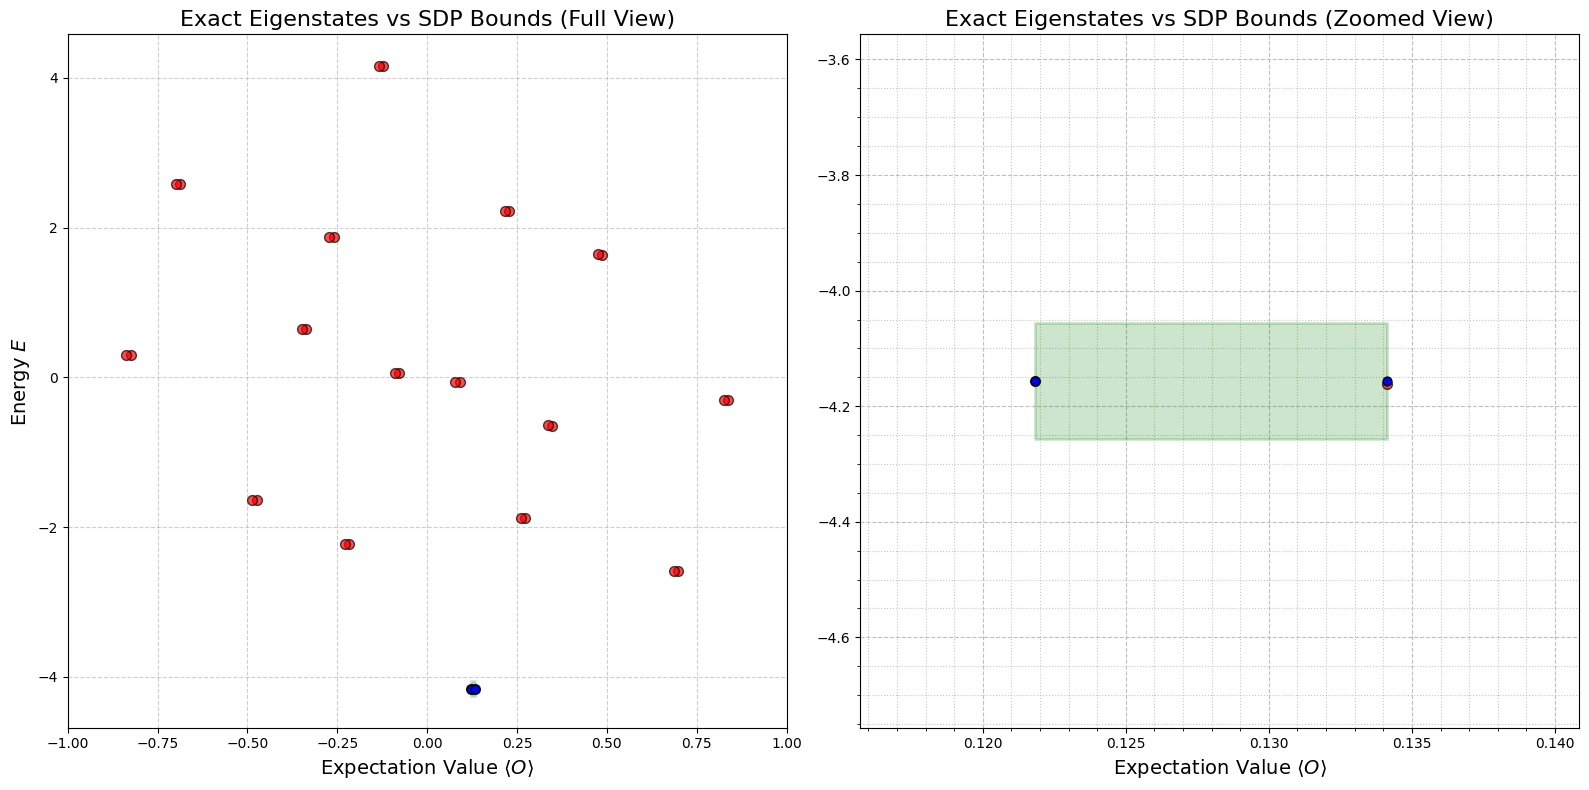

In [10]:


index = 1
energy = eigenvalues[index]

min_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, True).value
print("The min value for density matrix sdp is", min_sdp_density_mat)


max_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, False).value

print("The max value for density matrix sdp is", max_sdp_density_mat)
print(expectation_values[0])
print(expectation_values[1])


print(f"Delta min bound: {min_sdp_density_mat - expectation_values[index]:.6}")
print(f"Delta max bound: {max_sdp_density_mat - expectation_values[index]:.6}")

print("***this is the value attained on the eigenstate, exact problem***")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.scatter(expectation_values, eigenvalues, 
            color='red', alpha=0.7, edgecolors='k', s=50, zorder=3)
rect1 = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                         max_sdp_density_mat - min_sdp_density_mat, 
                         2 * eps, 
                         linewidth=2, edgecolor='green', facecolor='green', alpha=0.2, zorder=2)
ax1.add_patch(rect1)

ax1.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
            color='blue', marker='o', s=40, edgecolors='k', zorder=4, label='SDP Bounds (Min/Max)')

ax1.set_xlim(-1, 1)
ax1.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax1.set_ylabel('Energy $E$', fontsize=14)
ax1.set_title('Exact Eigenstates vs SDP Bounds (Full View)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)


ax2.scatter(expectation_values, eigenvalues, 
            color='red', alpha=0.7, edgecolors='k', s=50, zorder=3)
rect2 = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                         max_sdp_density_mat - min_sdp_density_mat, 
                         2 * eps, 
                         linewidth=2, edgecolor='green', facecolor='green', alpha=0.2, zorder=2)
ax2.add_patch(rect2)

ax2.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
            color='blue', marker='o', s=40, edgecolors='k', zorder=4, label='SDP Bounds (Min/Max)')

ax2.set_xlim(min_sdp_density_mat - 0.05*np.abs(min_sdp_density_mat), max_sdp_density_mat + 0.05*np.abs(max_sdp_density_mat))
# ax2.set_xlim(-1, 1)
# ax2.set_xlim(-0.25, 0)
ax2.set_ylim(energy - eps - 0.5 , energy + eps + 0.5)
ax2.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax2.set_title('Exact Eigenstates vs SDP Bounds (Zoomed View)', fontsize=16)
ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='--', alpha=0.8, zorder=0)
ax2.grid(True, which='minor', linestyle=':', alpha=0.7, zorder=0)

plt.tight_layout()
plt.show()

Solving SDP min...
problem status =  optimal
Solving SDP max...
problem status =  optimal
The min value density/moment -0.11731178295522951 -0.6470388313878489
The max value density/moment -0.10653023083479632 0.43498114651828584
Delta min bound: -0.540508
Delta max bound: 0.541512
Density matrix bound width: 1.078155e-02
Moment bound width: 1.082020e+00


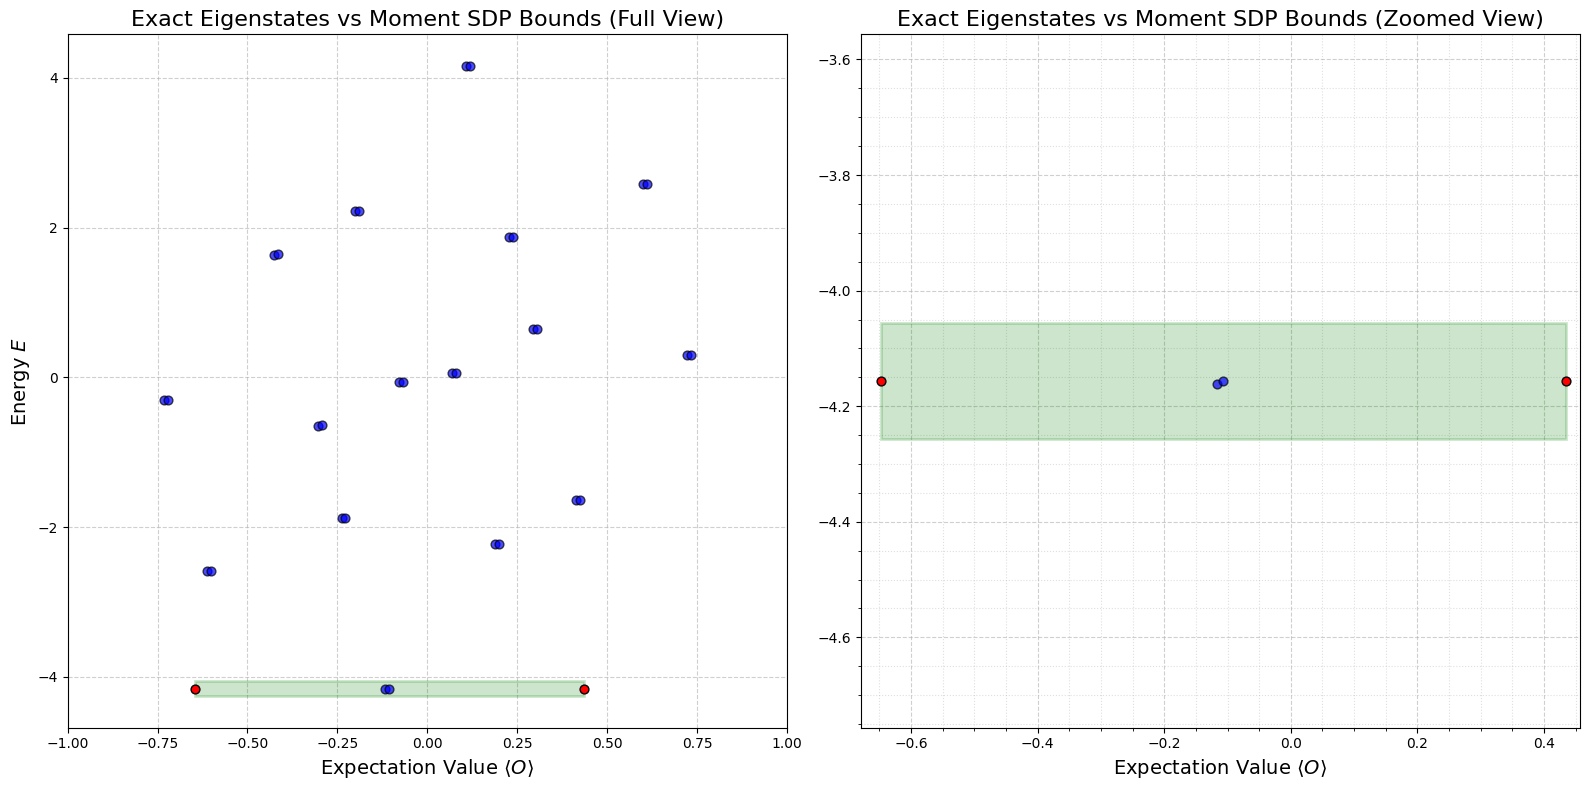

In [2]:

print("Solving SDP min...")

# start = time.time()
min_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, True)
# end = time.time()
print("problem status = ",min_sdp_moment.status)
# min_sdp_moment=prob.value


print("Solving SDP max...")

# start = time.time()
max_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, False)
# end = time.time()
print("problem status = ",max_sdp_moment.status)
# max_sdp_moment=prob.value



print("The min value density/moment",min_sdp_density_mat, min_sdp_moment.value)
print("The max value density/moment",max_sdp_density_mat, max_sdp_moment.value)
# print("The max value is", max_sdp_moment)

min_delta =  min_sdp_moment.value - expectation_values[index]
max_delta = max_sdp_moment.value - expectation_values[index]

print(f"Delta min bound: {min_delta:.6}")
print(f"Delta max bound: {max_delta:.6}")

print(f"Density matrix bound width: {max_sdp_density_mat - min_sdp_density_mat:.6e}")
print(f"Moment bound width: {max_sdp_moment.value - min_sdp_moment.value:.6e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.scatter(expectation_values, eigenvalues, 
            color='blue', alpha=0.7, edgecolors='k', s=40, zorder=3)
rect1 = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                         max_sdp_moment.value - min_sdp_moment.value, 
                         2 * eps, 
                         linewidth=2, edgecolor='green', facecolor='green', alpha=0.2, zorder=2)
ax1.add_patch(rect1)

ax1.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
            color='red', marker='o', s=40, edgecolors='k', zorder=4, label='SDP Bounds (Min/Max)')
ax1.set_xlim(-1, 1)
ax1.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax1.set_ylabel('Energy $E$', fontsize=14)
ax1.set_title('Exact Eigenstates vs Moment SDP Bounds (Full View)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)


ax2.scatter(expectation_values, eigenvalues, 
            color='blue', alpha=0.7, edgecolors='k', s=40, zorder=3)
rect2 = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                         max_sdp_moment.value - min_sdp_moment.value, 
                         2 * eps, 
                         linewidth=2, edgecolor='green', facecolor='green', alpha=0.2, zorder=2)
ax2.add_patch(rect2)

ax2.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
            color='red', marker='o', s=40, edgecolors='k', zorder=4, label='SDP Bounds (Min/Max)')
# ax2.set_xlim(-1, 1)
ax2.set_ylim(energy - eps - 0.5, energy + eps + 0.5)
ax2.set_xlim(min_sdp_moment.value - 0.05 *np.abs(min_sdp_moment.value), max_sdp_moment.value + 0.05* np.abs(max_sdp_moment.value))
ax2.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax2.set_title('Exact Eigenstates vs Moment SDP Bounds (Zoomed View)', fontsize=16)

ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='--', alpha=0.6, zorder=0)
ax2.grid(True, which='minor', linestyle=':', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

In [28]:
npa_level = 2
basis = NPA(npa_level, 5, _, True)
print(len(basis))

106


Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Solving moment SDP max...
Delta min bound density matrix: -2.2181e-08
Delta max bound density matrix: 7.71077e-08
Delta min bound moment matrix: -0.418529
Delta max bound moment matrix: 0.413769
The min bound density/moment 0.07631038530777298 -0.3422184983753367
The max bound density/moment 0.07631048459638623 0.490079875061335
Min bound difference: 0.4185288836831097
Max bound difference: 0.41376939046494876
Density matrix bound width: 9.928861e-08
Moment matrix bound width: 8.322984e-01


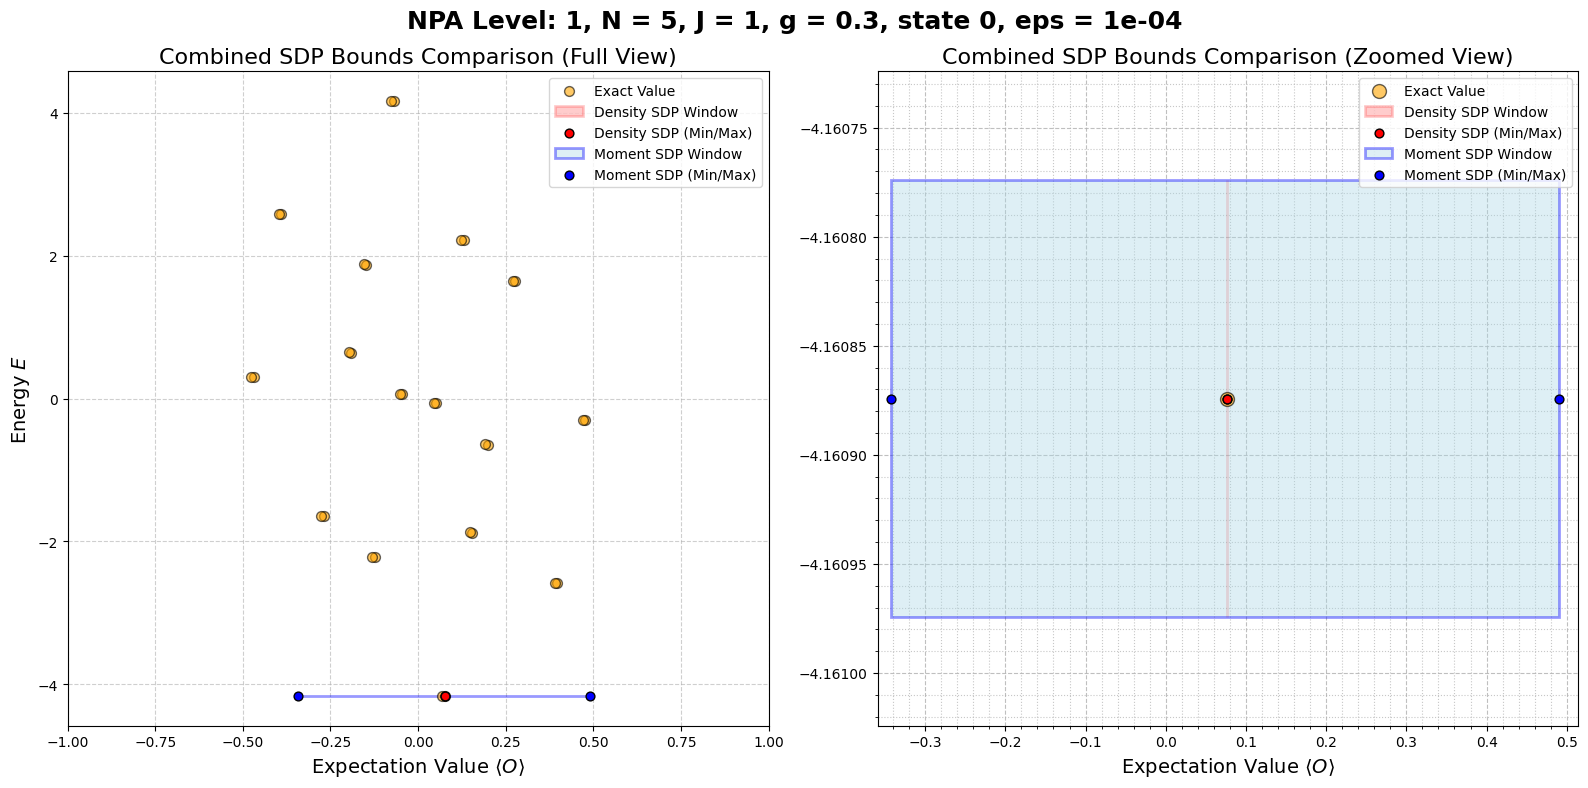

In [1]:
from Moment import *
N = 5

J = 1
g = 0.3
npa_level = 1
index = 0
rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
H = build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)
basis = NPA(npa_level, N, _, True)


eps = 0.0001

#exact diagonalization

eigenvalues, eigenvectors = load_eigen(f"eigenvalues{N}.npz", H)
expectation_values = []

expectation_values = get_expectation(N, N//2, rand_op1, eigenvalues, eigenvectors)

#density matrix sdp

energy = eigenvalues[index]
print("Solving density matrix SDP min...")
min_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, True).value

print("Solving density matrix SDP max...")
max_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, False).value

# moment sdp

print("Solving moment SDP min...")

# start = time.time()
min_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, True)
# end = time.time()

print("Solving moment SDP max...")

# start = time.time()
max_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, False)
# end = time.time()

min_delta =  min_sdp_moment.value - expectation_values[index]
max_delta = max_sdp_moment.value - expectation_values[index]

print(f"Delta min bound density matrix: {min_sdp_density_mat - expectation_values[index]:.6}")
print(f"Delta max bound density matrix: {max_sdp_density_mat - expectation_values[index]:.6}")

print(f"Delta min bound moment matrix: {min_delta:.6}")
print(f"Delta max bound moment matrix: {max_delta:.6}")

print("The min bound density/moment",min_sdp_density_mat, min_sdp_moment.value)
print("The max bound density/moment",max_sdp_density_mat, max_sdp_moment.value)
print(f"Min bound difference: {np.abs(min_sdp_density_mat - min_sdp_moment.value)}")
print(f"Max bound difference: {np.abs(max_sdp_moment.value - max_sdp_density_mat)}")
# print("Exact expectation value",expectation_values[index])
# print("Exact expectation value",expectation_values[index - 1])

print(f"Density matrix bound width: {max_sdp_density_mat - min_sdp_density_mat:.6e}")
print(f"Moment matrix bound width: {max_sdp_moment.value - min_sdp_moment.value:.6e}")



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f'NPA Level: {npa_level}, N = {N}, J = {J}, g = {g}, state {index}, eps = {eps:.0e}', fontsize=18, fontweight='bold')

ax1.scatter(expectation_values, eigenvalues, 
            color='orange', alpha=0.6, edgecolors='k', s=50, zorder=3, label='Exact Value')

rect1_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                         max_sdp_density_mat - min_sdp_density_mat, 
                         2 * eps, 
                         linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
ax1.add_patch(rect1_dens)

ax1.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
            color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')

rect1_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                         max_sdp_moment.value - min_sdp_moment.value, 
                         2 * eps, 
                         linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
ax1.add_patch(rect1_mom)

ax1.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
            color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')

ax1.set_xlim(-1, 1)
ax1.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax1.set_ylabel('Energy $E$', fontsize=14)
ax1.set_title('Combined SDP Bounds Comparison (Full View)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax1.legend(loc='upper right')


ax2.scatter(expectation_values, eigenvalues, 
            color='orange', alpha=0.6, edgecolors='k', s=100, zorder=3, label='Exact Value')

rect2_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                         max_sdp_density_mat - min_sdp_density_mat, 
                         2 * eps, 
                         linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
ax2.add_patch(rect2_dens)

ax2.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
            color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')

rect2_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                         max_sdp_moment.value - min_sdp_moment.value, 
                         2 * eps, 
                         linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
ax2.add_patch(rect2_mom)

ax2.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
            color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')

zoom_min = min(min_sdp_density_mat, min_sdp_moment.value)
zoom_max = max(max_sdp_density_mat, max_sdp_moment.value)

ax2.set_xlim(zoom_min - 0.05 * np.abs(zoom_min), zoom_max + 0.05 * np.abs(zoom_max))
ax2.set_ylim(energy - eps - 0.5 * (eps), energy + eps + 0.5 * (eps))

ax2.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
ax2.set_title('Combined SDP Bounds Comparison (Zoomed View)', fontsize=16)

ax2.minorticks_on()
ax2.grid(True, which='major', linestyle='--', alpha=0.8, zorder=0)
ax2.grid(True, which='minor', linestyle=':', alpha=0.7, zorder=0)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 18.8865 seconds
Solving moment SDP max...
Elapsed time: 20.5102 seconds
Delta min bound density matrix: -0.00234259
Delta max bound density matrix: 5.10956e-09
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -5.51062e-11
The min bound density/moment 0.023144583311654032 0.023144924921909116
The max bound density/moment 0.025487181753762994 0.02548717658909321
Min bound difference: 3.4161025508350207e-07
Max bound difference: 5.164669785590048e-09
Density matrix bound width: 2.342598e-03
Moment matrix bound width: 2.342252e-03


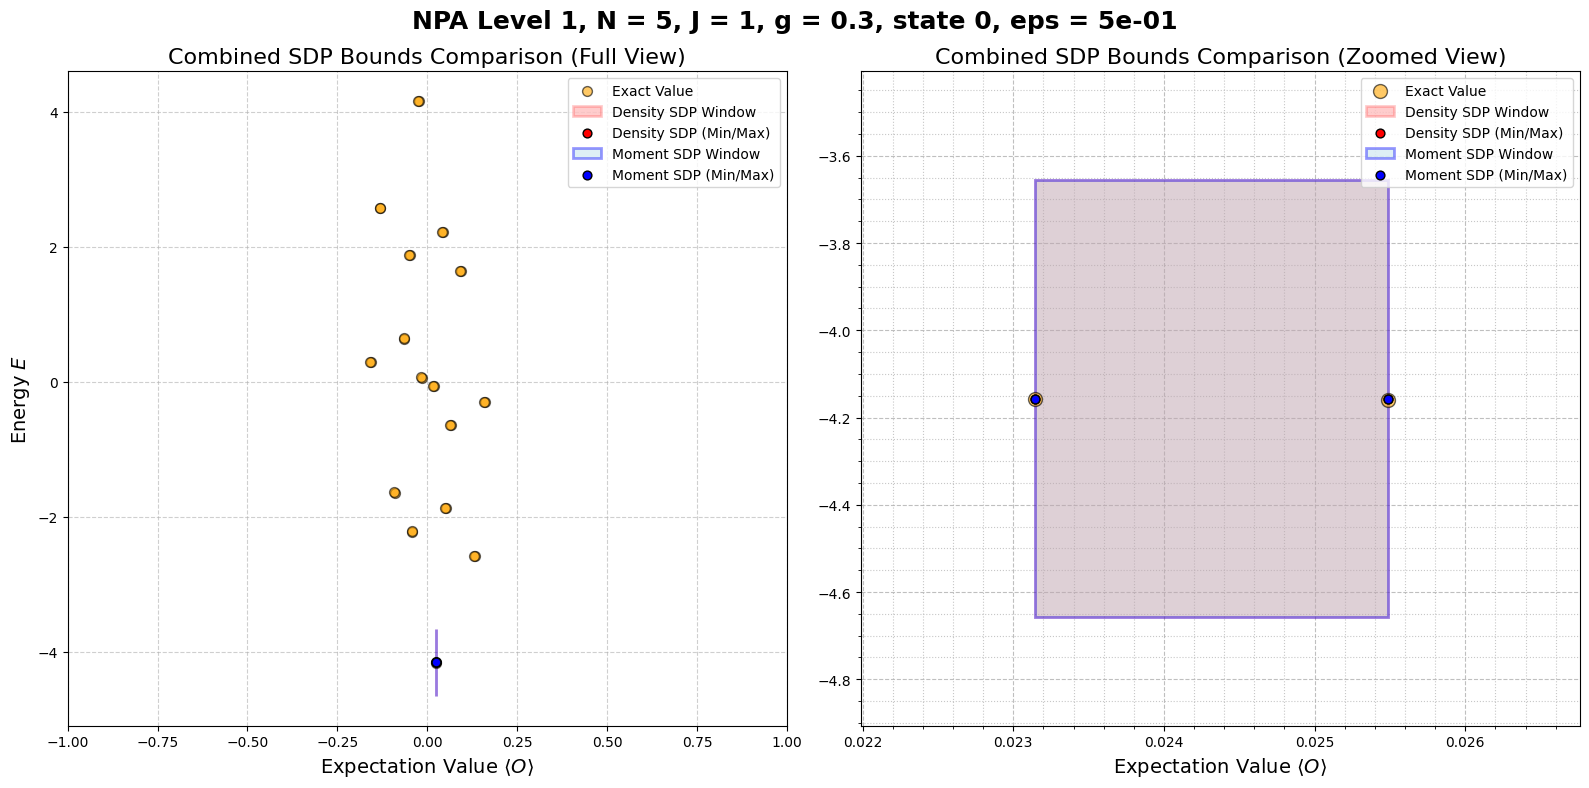

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.1576 seconds
Solving moment SDP max...
Elapsed time: 19.3667 seconds
Delta min bound density matrix: -0.00234259
Delta max bound density matrix: 5.10956e-09
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -5.51062e-11
The min bound density/moment 0.023144583311654032 0.023144924921909116
The max bound density/moment 0.025487181753762994 0.02548717658909321
Min bound difference: 3.4161025508350207e-07
Max bound difference: 5.164669785590048e-09
Density matrix bound width: 2.342598e-03
Moment matrix bound width: 2.342252e-03


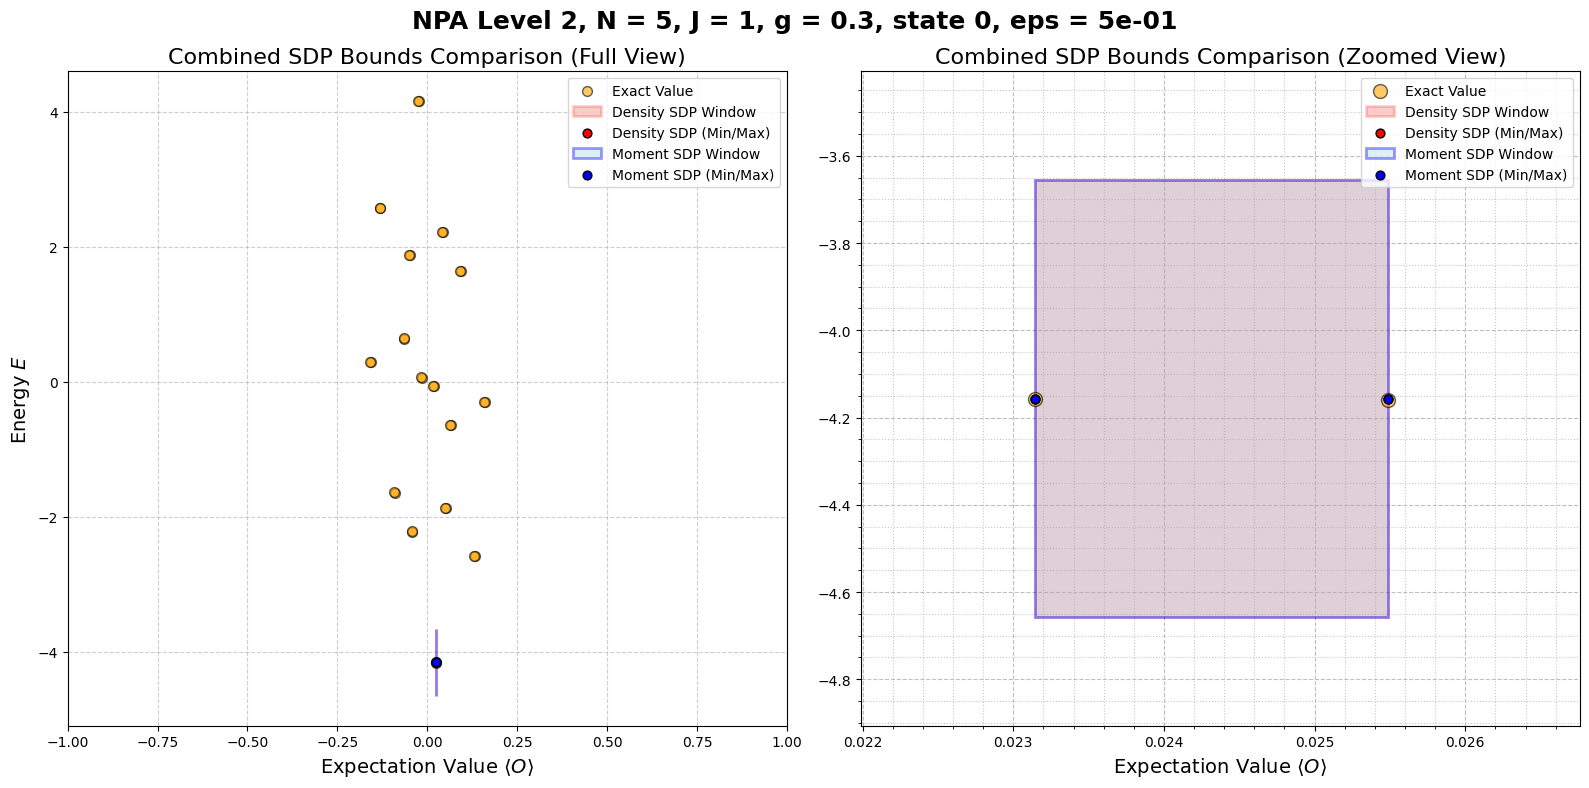

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.6258 seconds
Solving moment SDP max...
Elapsed time: 18.9064 seconds
Delta min bound density matrix: -0.00234225
Delta max bound density matrix: 9.13915e-10
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: 9.43664e-11
The min bound density/moment 0.02314492210153621 0.02314492481081727
The max bound density/moment 0.025487177558114193 0.025487176738565764
Min bound difference: 2.7092810633844167e-09
Max bound difference: 8.195484291206867e-10
Density matrix bound width: 2.342255e-03
Moment matrix bound width: 2.342252e-03


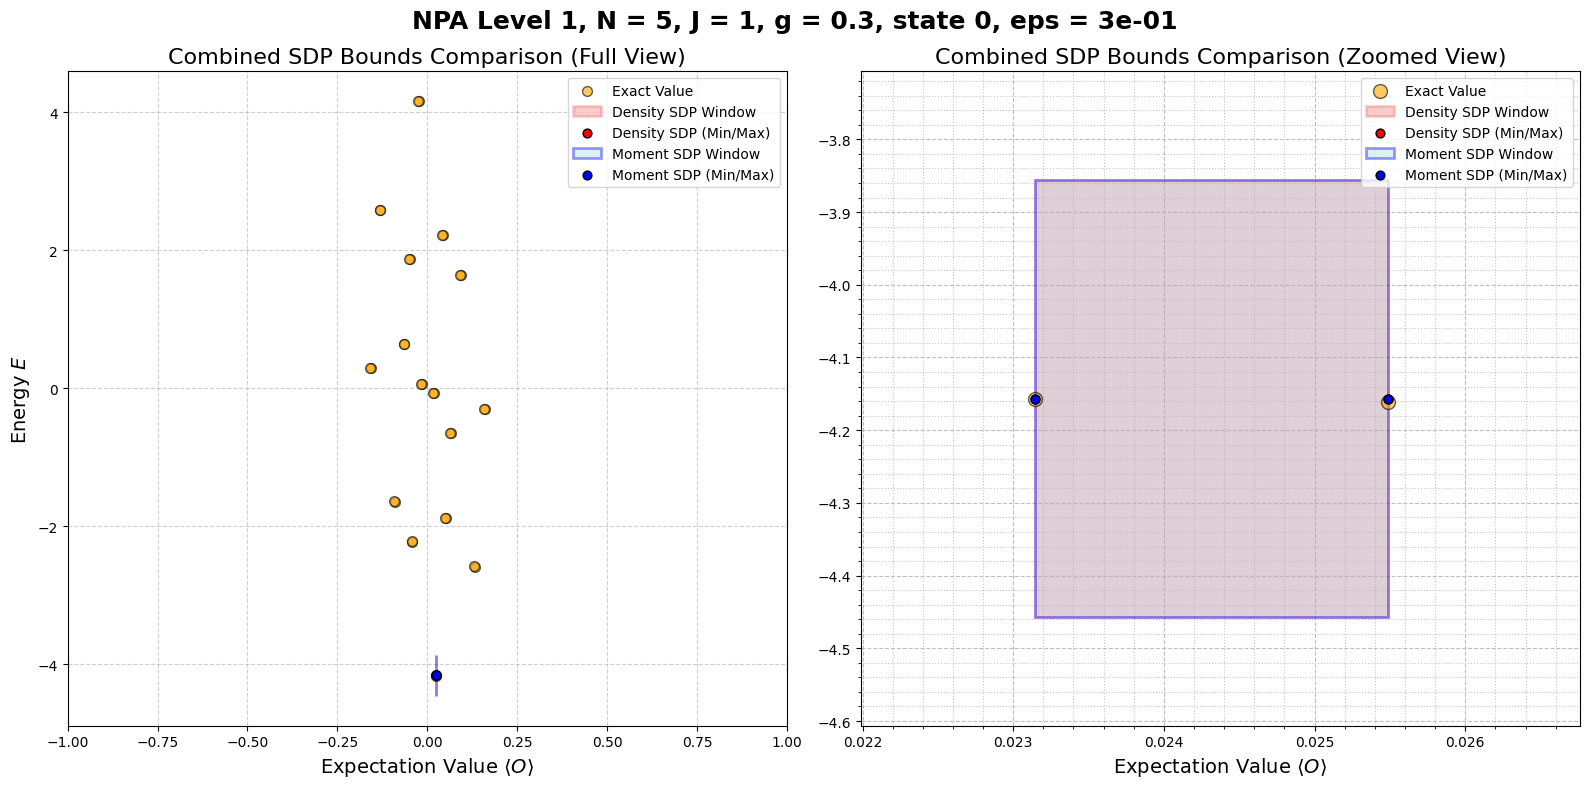

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.9417 seconds
Solving moment SDP max...
Elapsed time: 18.8393 seconds
Delta min bound density matrix: -0.00234225
Delta max bound density matrix: 9.13915e-10
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: 9.43664e-11
The min bound density/moment 0.02314492210153621 0.02314492481081727
The max bound density/moment 0.025487177558114193 0.025487176738565764
Min bound difference: 2.7092810633844167e-09
Max bound difference: 8.195484291206867e-10
Density matrix bound width: 2.342255e-03
Moment matrix bound width: 2.342252e-03


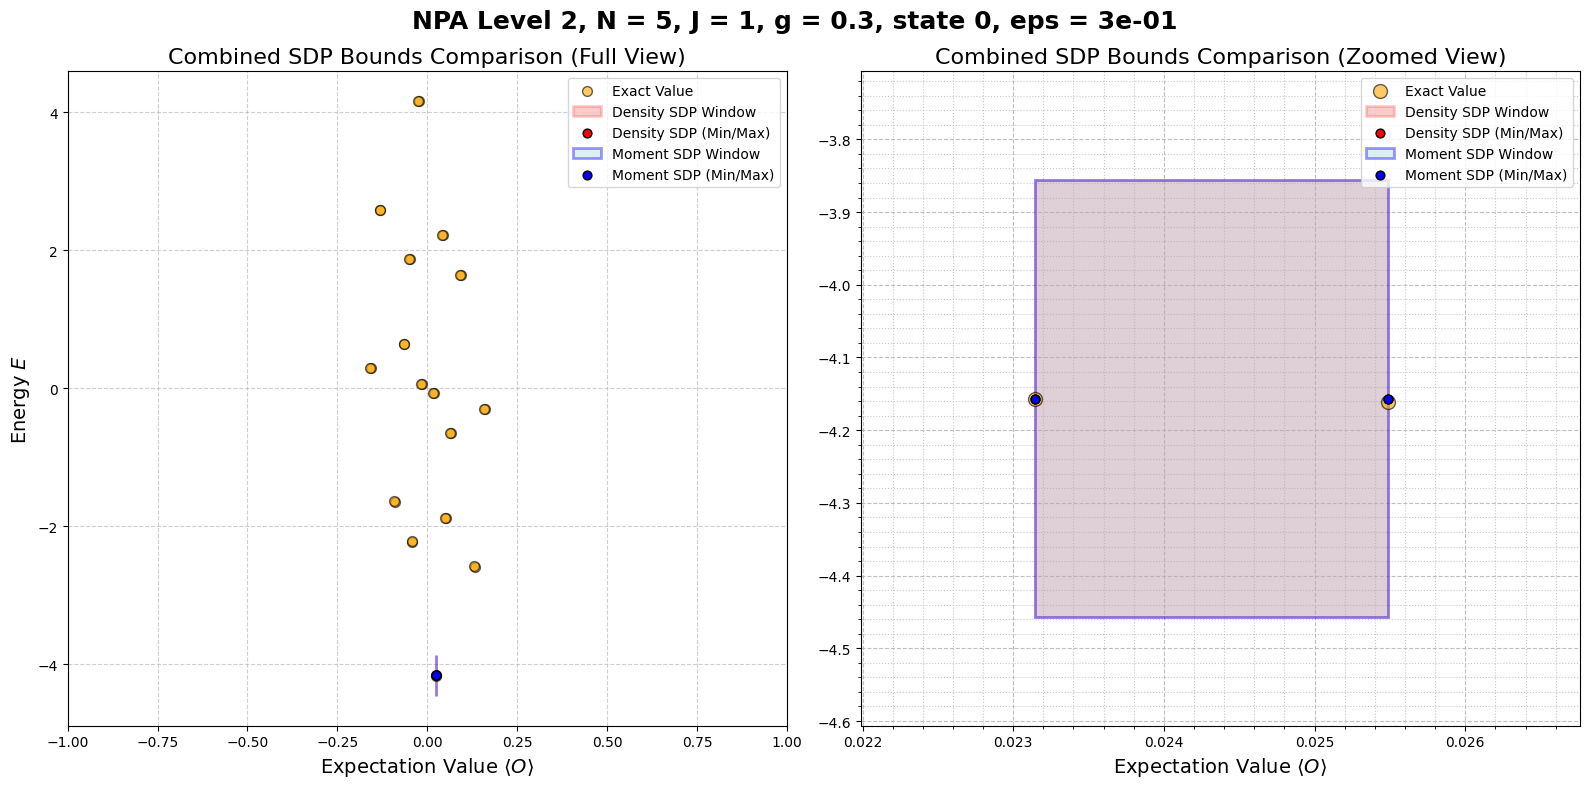

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 19.8013 seconds
Solving moment SDP max...
Elapsed time: 19.9634 seconds
Delta min bound density matrix: -0.00234233
Delta max bound density matrix: 6.28411e-12
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -6.58788e-11
The min bound density/moment 0.023144851471334882 0.023144924767956276
The max bound density/moment 0.025487176650483473 0.025487176578320565
Min bound difference: 7.329662139385351e-08
Max bound difference: 7.216290759393118e-11
Density matrix bound width: 2.342325e-03
Moment matrix bound width: 2.342252e-03


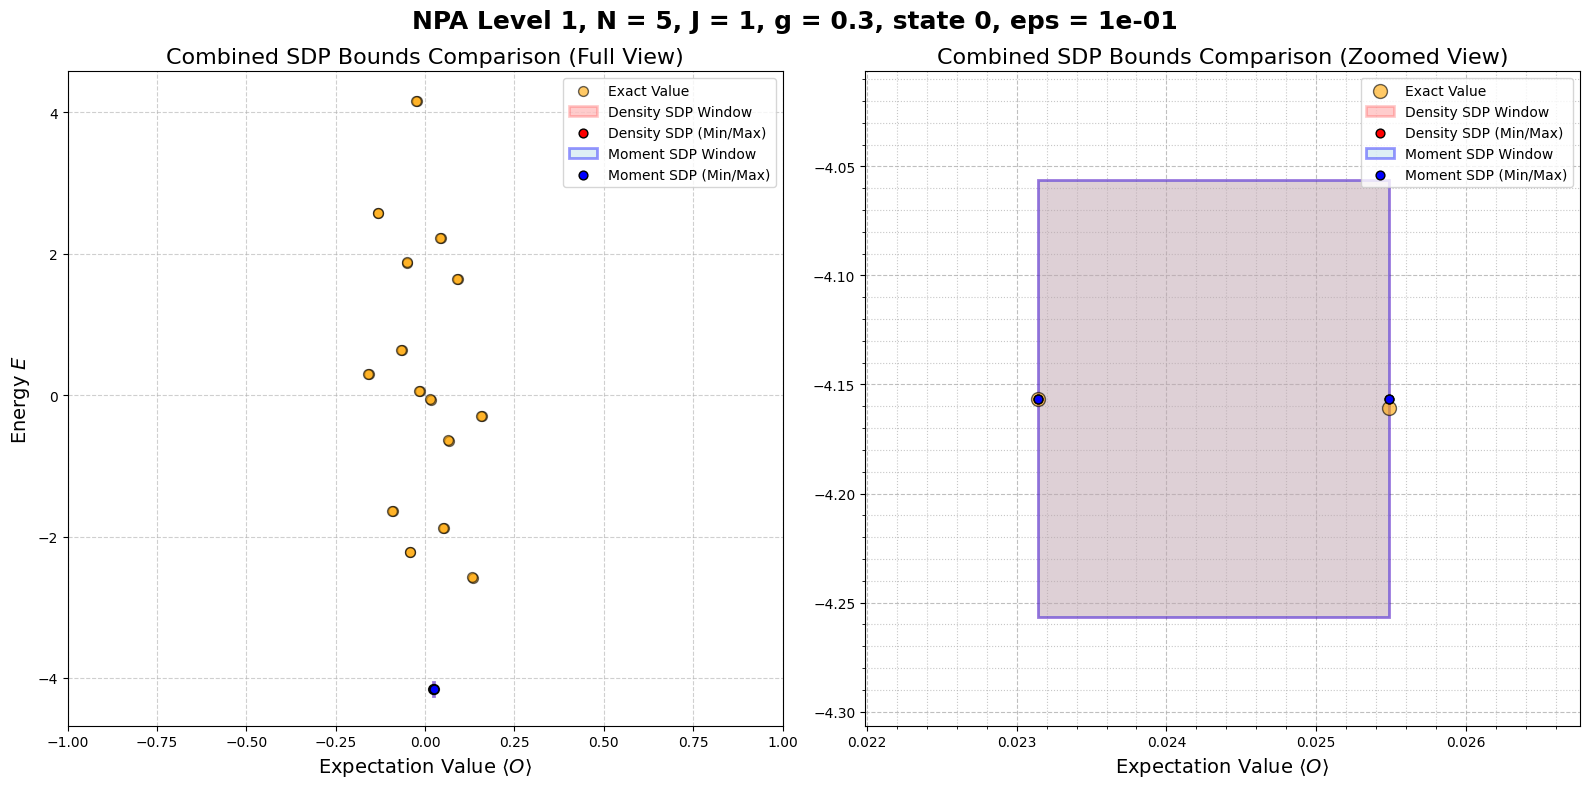

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 19.0137 seconds
Solving moment SDP max...
Elapsed time: 20.6778 seconds
Delta min bound density matrix: -0.00234233
Delta max bound density matrix: 6.28411e-12
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -6.58788e-11
The min bound density/moment 0.023144851471334882 0.023144924767956276
The max bound density/moment 0.025487176650483473 0.025487176578320565
Min bound difference: 7.329662139385351e-08
Max bound difference: 7.216290759393118e-11
Density matrix bound width: 2.342325e-03
Moment matrix bound width: 2.342252e-03


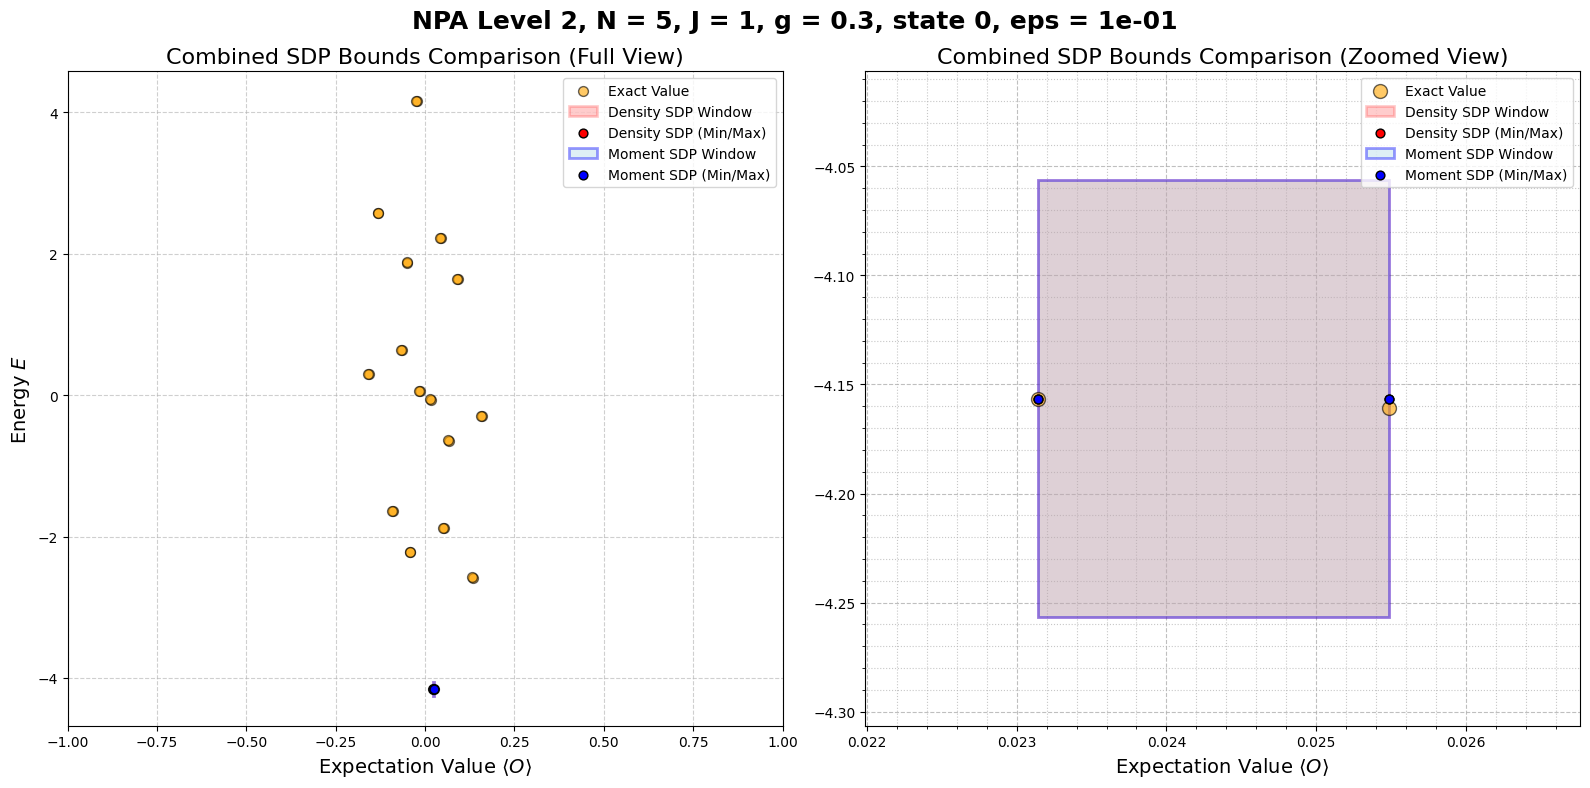

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.0350 seconds
Solving moment SDP max...
Elapsed time: 18.6810 seconds
Delta min bound density matrix: -0.00234226
Delta max bound density matrix: 8.86548e-08
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: 1.10019e-10
The min bound density/moment 0.023144921600947943 0.023144924854602813
The max bound density/moment 0.02548726529896589 0.025487176754218202
Min bound difference: 3.2536548698336443e-09
Max bound difference: 8.854474768671405e-08
Density matrix bound width: 2.342344e-03
Moment matrix bound width: 2.342252e-03


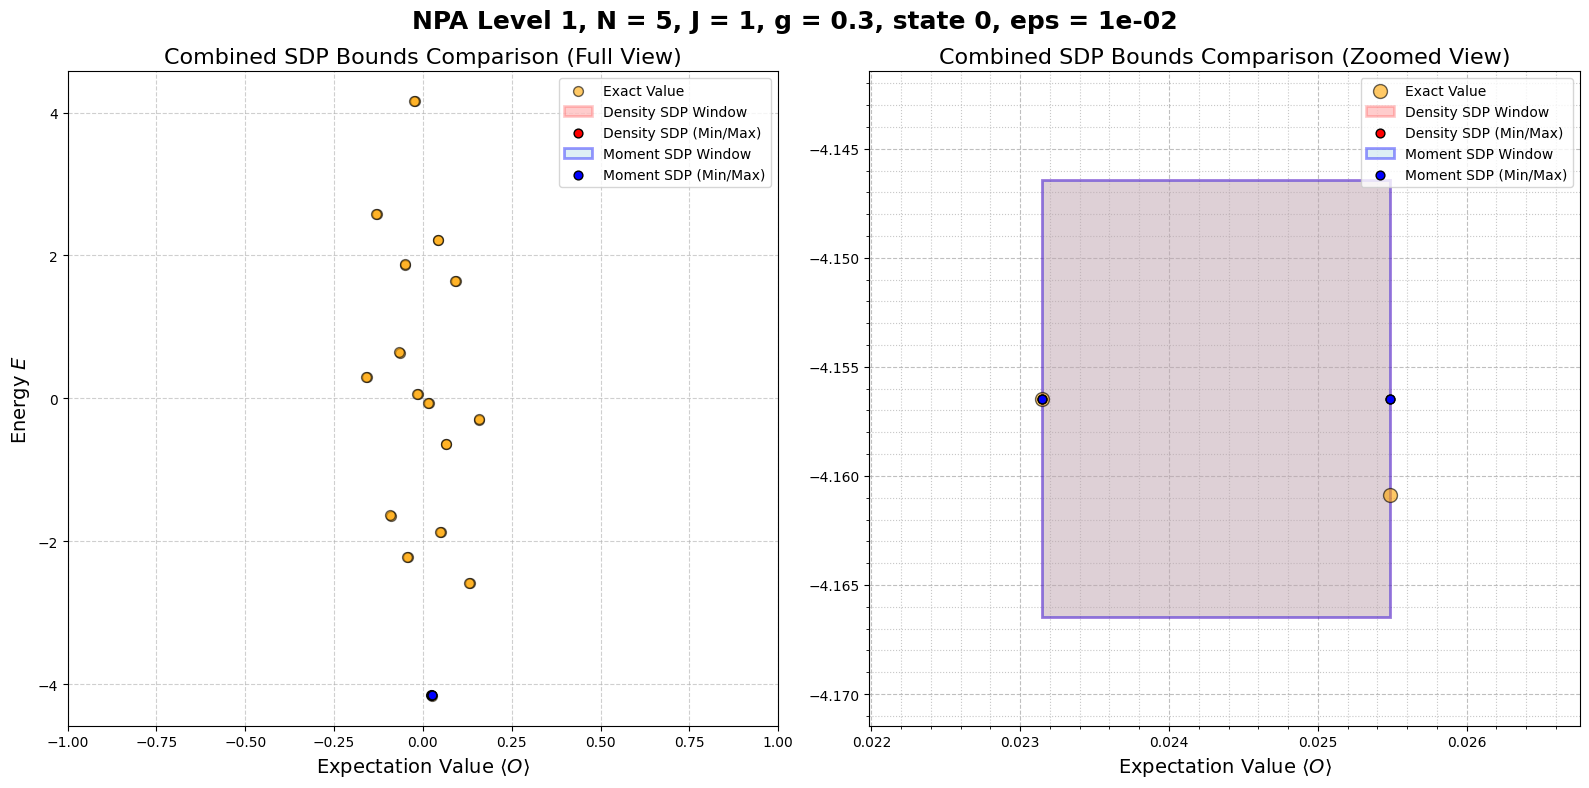

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.9424 seconds
Solving moment SDP max...
Elapsed time: 18.6067 seconds
Delta min bound density matrix: -0.00234226
Delta max bound density matrix: 8.86548e-08
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: 1.10019e-10
The min bound density/moment 0.023144921600947943 0.023144924854602813
The max bound density/moment 0.02548726529896589 0.025487176754218202
Min bound difference: 3.2536548698336443e-09
Max bound difference: 8.854474768671405e-08
Density matrix bound width: 2.342344e-03
Moment matrix bound width: 2.342252e-03


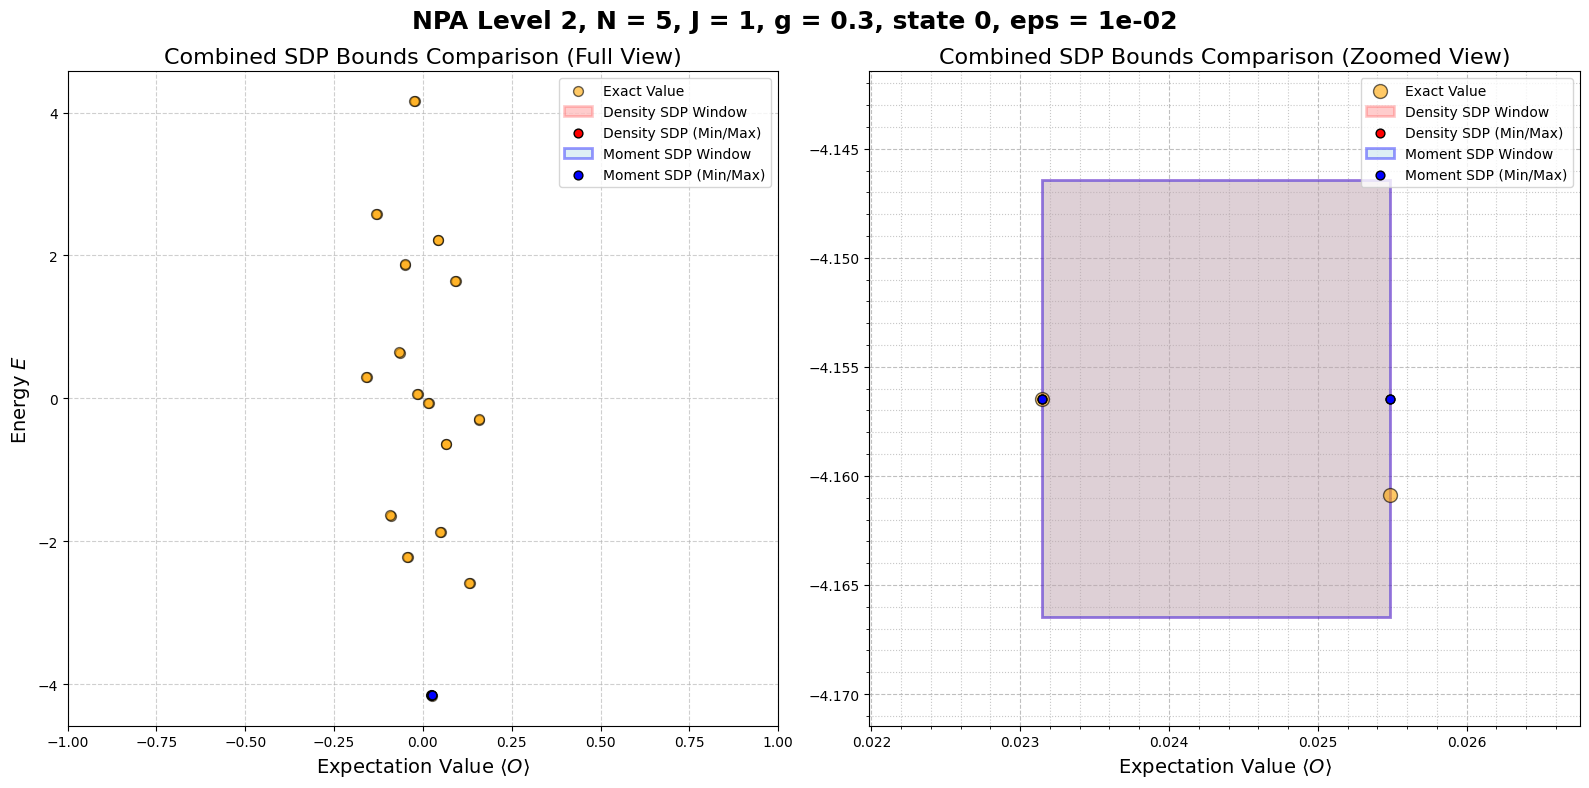

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.8111 seconds
Solving moment SDP max...
Elapsed time: 19.8014 seconds
Delta min bound density matrix: -0.00234245
Delta max bound density matrix: -0.00234219
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.023144730463848823 0.023144924714227036
The max bound density/moment 0.023144989907649238 0.0231449267563161
Min bound difference: 1.942503782131899e-07
Max bound difference: 6.315133313852805e-08
Density matrix bound width: 2.594438e-07
Moment matrix bound width: 2.042089e-09


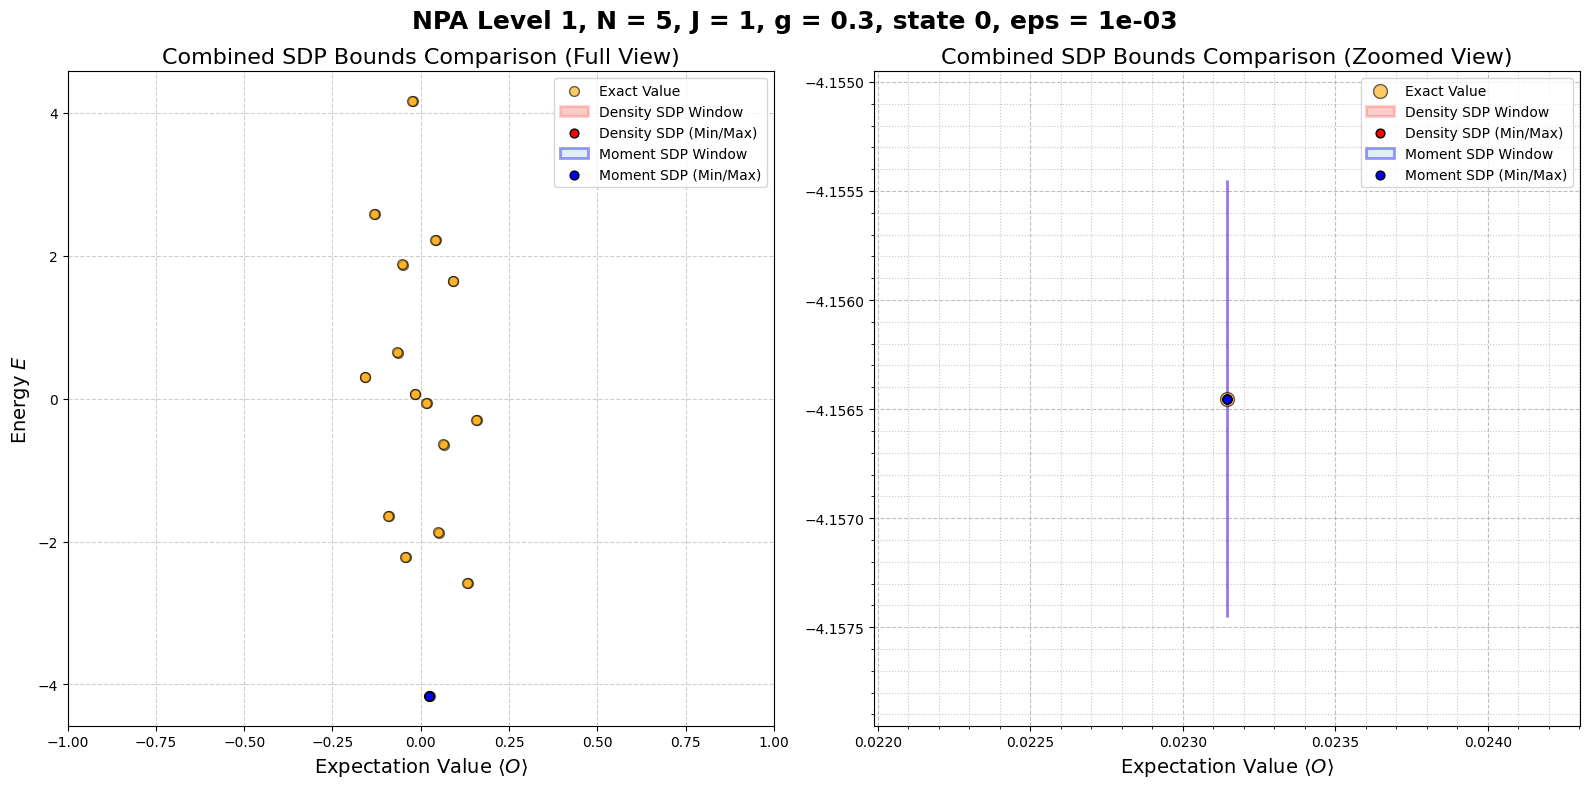

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.0218 seconds
Solving moment SDP max...
Elapsed time: 19.6251 seconds
Delta min bound density matrix: -0.00234245
Delta max bound density matrix: -0.00234219
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.023144730463848823 0.023144924714227036
The max bound density/moment 0.023144989907649238 0.0231449267563161
Min bound difference: 1.942503782131899e-07
Max bound difference: 6.315133313852805e-08
Density matrix bound width: 2.594438e-07
Moment matrix bound width: 2.042089e-09


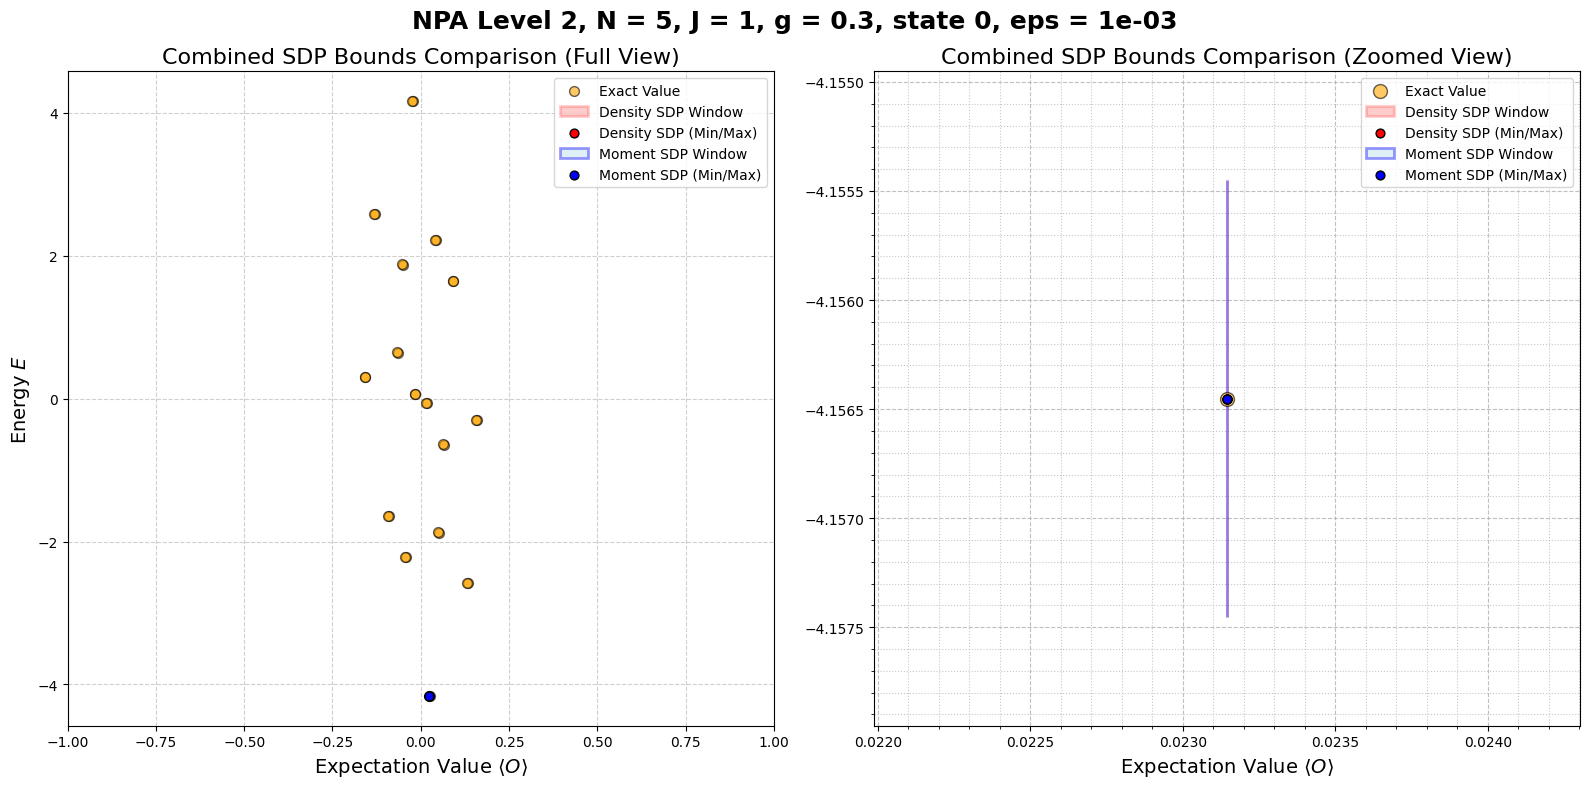

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.1524 seconds
Solving moment SDP max...
Elapsed time: 21.6685 seconds
Delta min bound density matrix: -0.00234226
Delta max bound density matrix: -0.00234225
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.02314491180172676 0.023144924641501752
The max bound density/moment 0.02314492492470857 0.023144925765709277
Min bound difference: 1.2839774993222974e-08
Max bound difference: 8.410007065751124e-10
Density matrix bound width: 1.312298e-08
Moment matrix bound width: 1.124208e-09


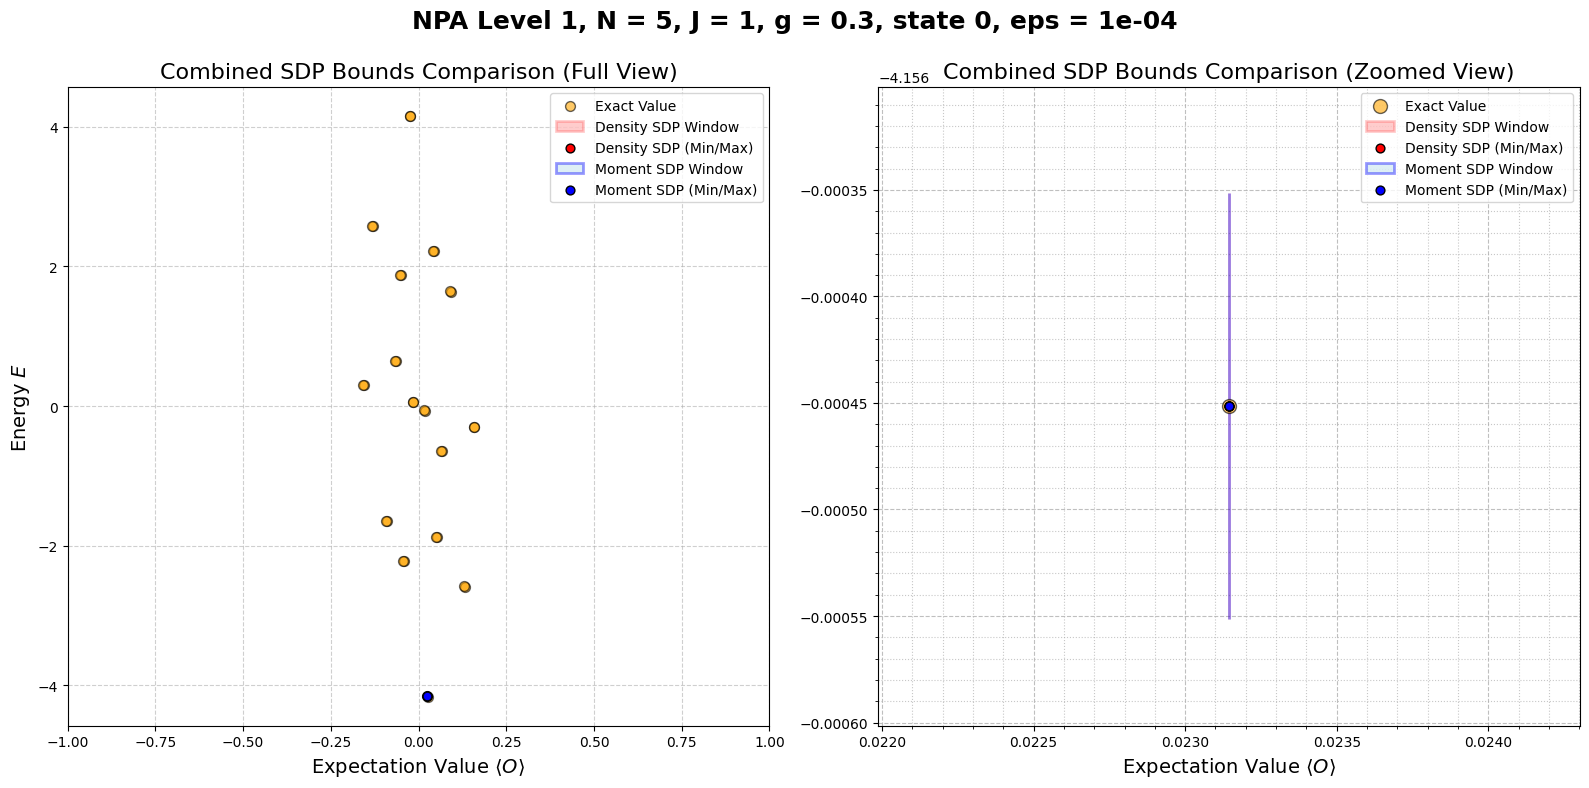

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.1193 seconds
Solving moment SDP max...
Elapsed time: 22.3095 seconds
Delta min bound density matrix: -0.00234226
Delta max bound density matrix: -0.00234225
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.02314491180172676 0.023144924641501752
The max bound density/moment 0.02314492492470857 0.023144925765709277
Min bound difference: 1.2839774993222974e-08
Max bound difference: 8.410007065751124e-10
Density matrix bound width: 1.312298e-08
Moment matrix bound width: 1.124208e-09


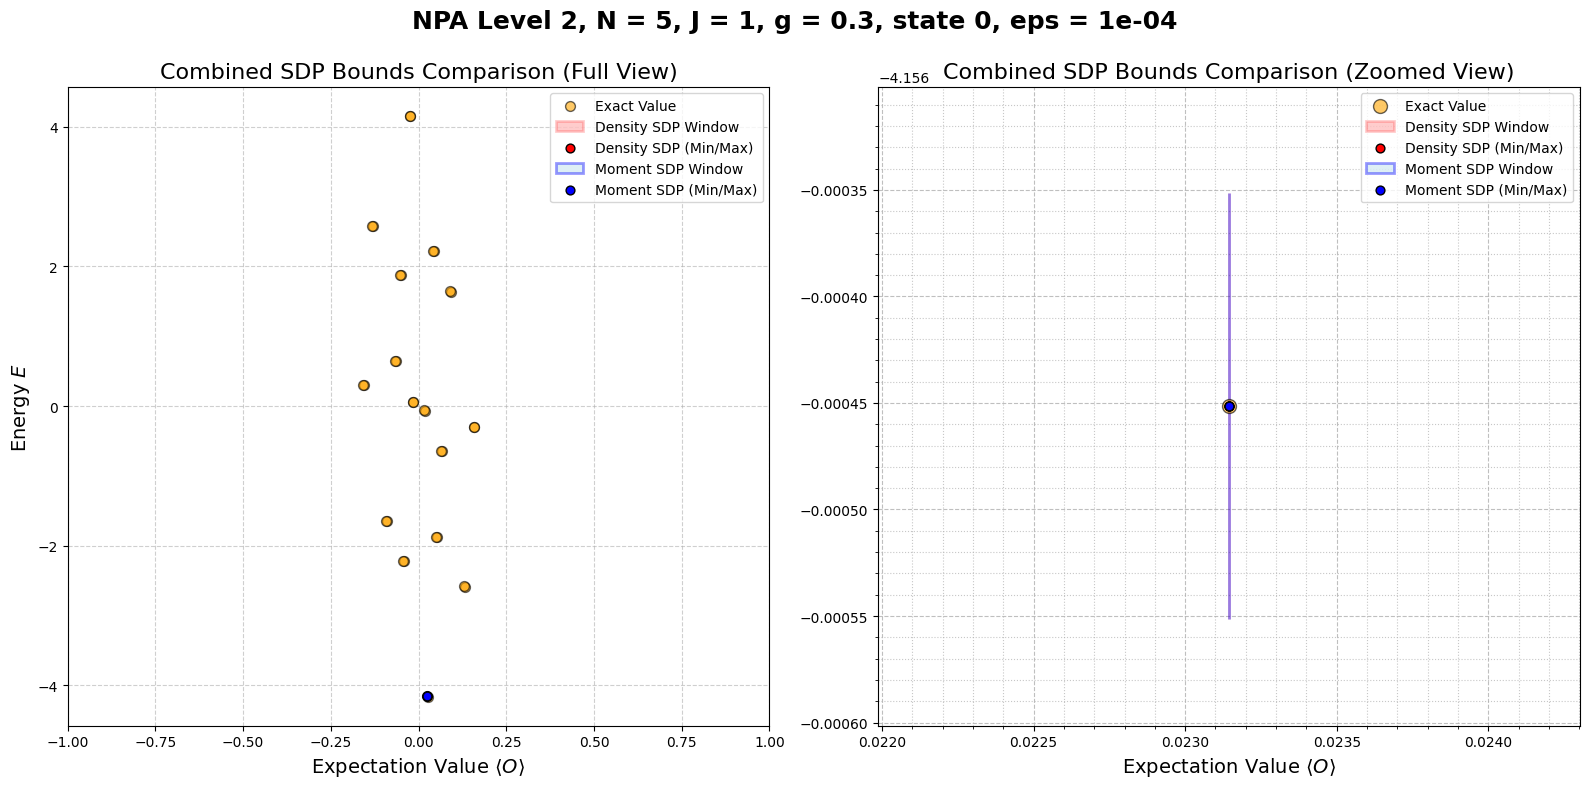

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.7292 seconds
Solving moment SDP max...
Elapsed time: 20.0452 seconds
Delta min bound density matrix: -0.00234225
Delta max bound density matrix: -0.00234208
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.023144924813590484 0.023144924425594952
The max bound density/moment 0.023145099082634873 0.02314492587498255
Min bound difference: 3.8799553153667787e-10
Max bound difference: 1.7320765232503588e-07
Density matrix bound width: 1.742690e-07
Moment matrix bound width: 1.449388e-09


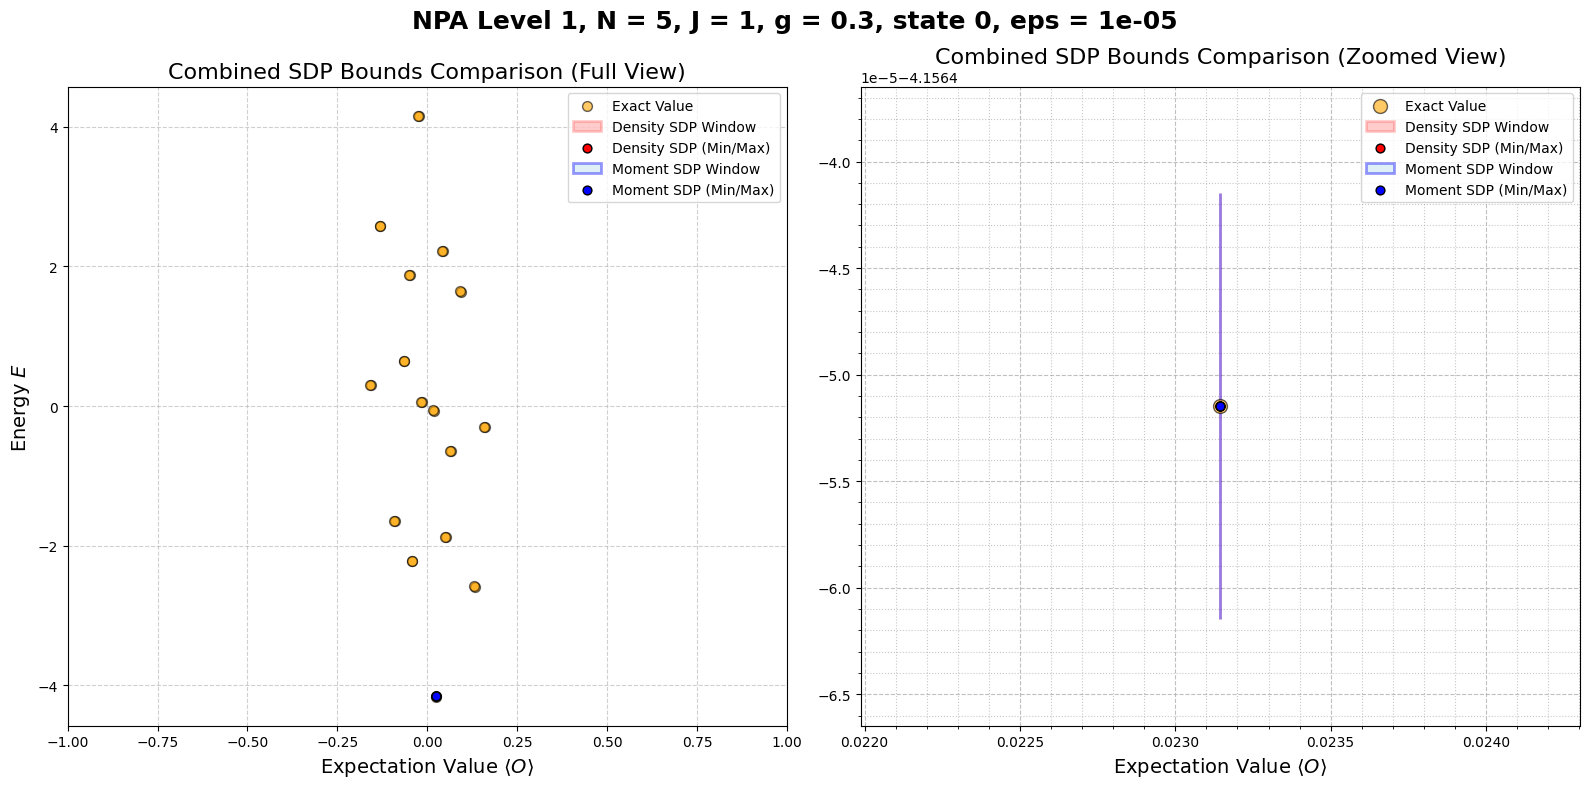

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.6325 seconds
Solving moment SDP max...
Elapsed time: 20.3353 seconds
Delta min bound density matrix: -0.00234225
Delta max bound density matrix: -0.00234208
Delta min bound moment matrix: -0.00234225
Delta max bound moment matrix: -0.00234225
The min bound density/moment 0.023144924813590484 0.023144924425594952
The max bound density/moment 0.023145099082634873 0.02314492587498255
Min bound difference: 3.8799553153667787e-10
Max bound difference: 1.7320765232503588e-07
Density matrix bound width: 1.742690e-07
Moment matrix bound width: 1.449388e-09


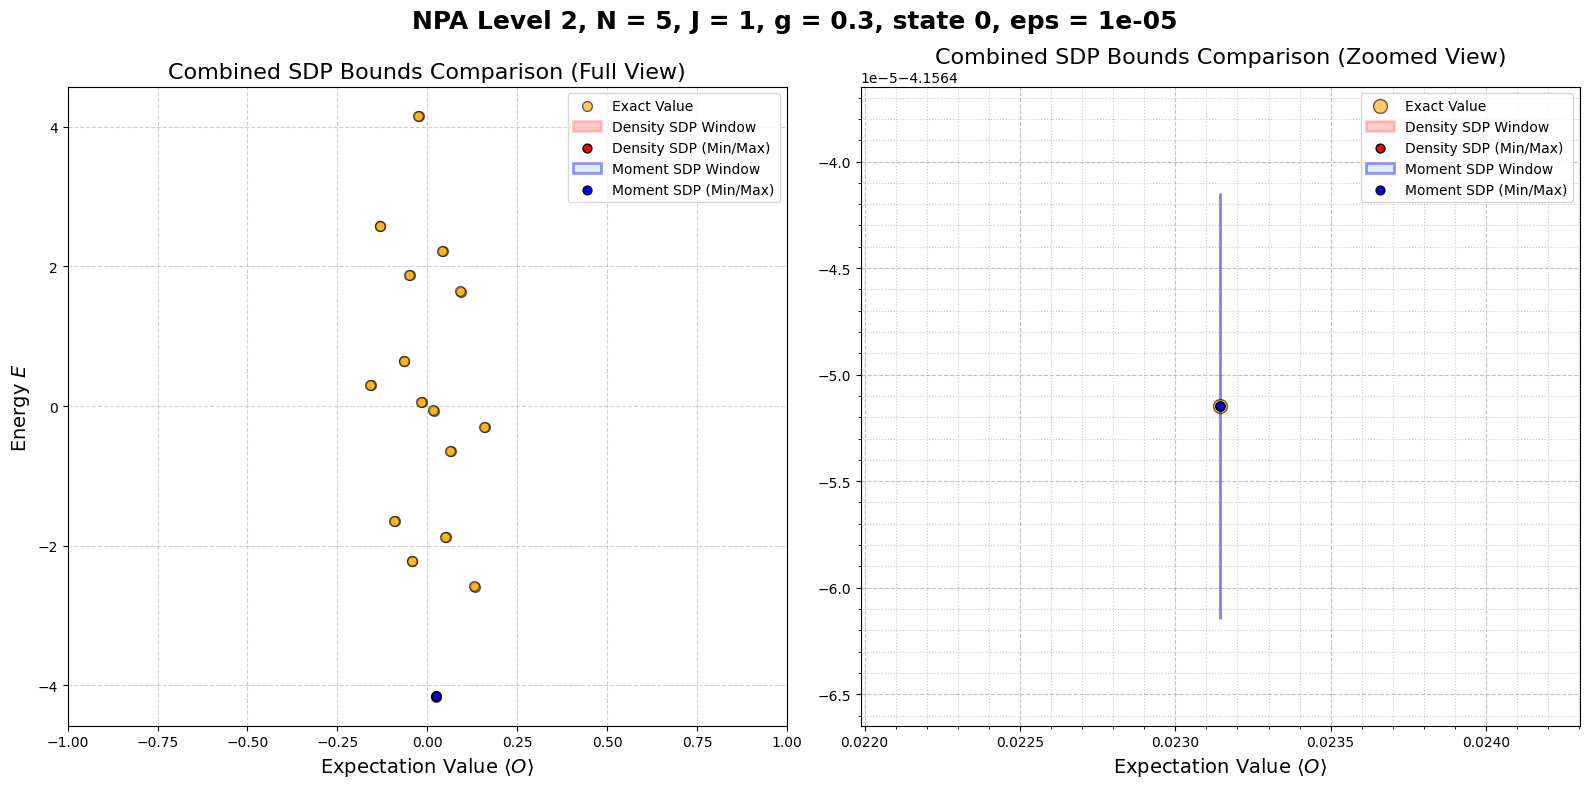

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.5596 seconds
Solving moment SDP max...
Elapsed time: 19.8166 seconds
Delta min bound density matrix: -3.41544e-07
Delta max bound density matrix: 0.00234226
Delta min bound moment matrix: 6.62289e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144583311654032 0.023144924921909116
The max bound density/moment 0.025487181753762994 0.02548717658909321
Min bound difference: 3.4161025508350207e-07
Max bound difference: 5.164669785590048e-09
Density matrix bound width: 2.342598e-03
Moment matrix bound width: 2.342252e-03


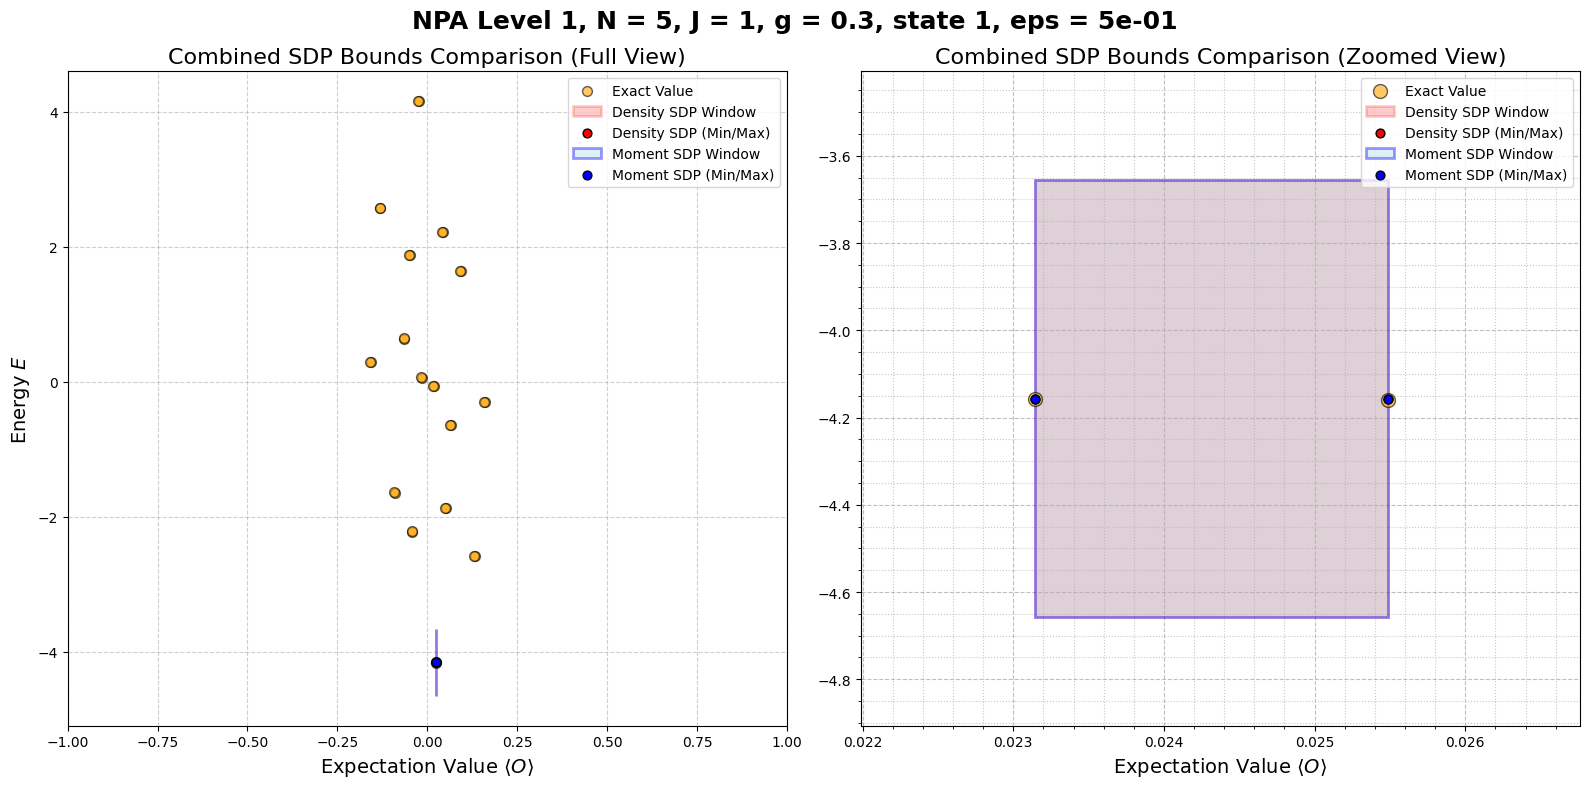

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.4001 seconds
Solving moment SDP max...
Elapsed time: 20.5188 seconds
Delta min bound density matrix: -3.41544e-07
Delta max bound density matrix: 0.00234226
Delta min bound moment matrix: 6.62289e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144583311654032 0.023144924921909116
The max bound density/moment 0.025487181753762994 0.02548717658909321
Min bound difference: 3.4161025508350207e-07
Max bound difference: 5.164669785590048e-09
Density matrix bound width: 2.342598e-03
Moment matrix bound width: 2.342252e-03


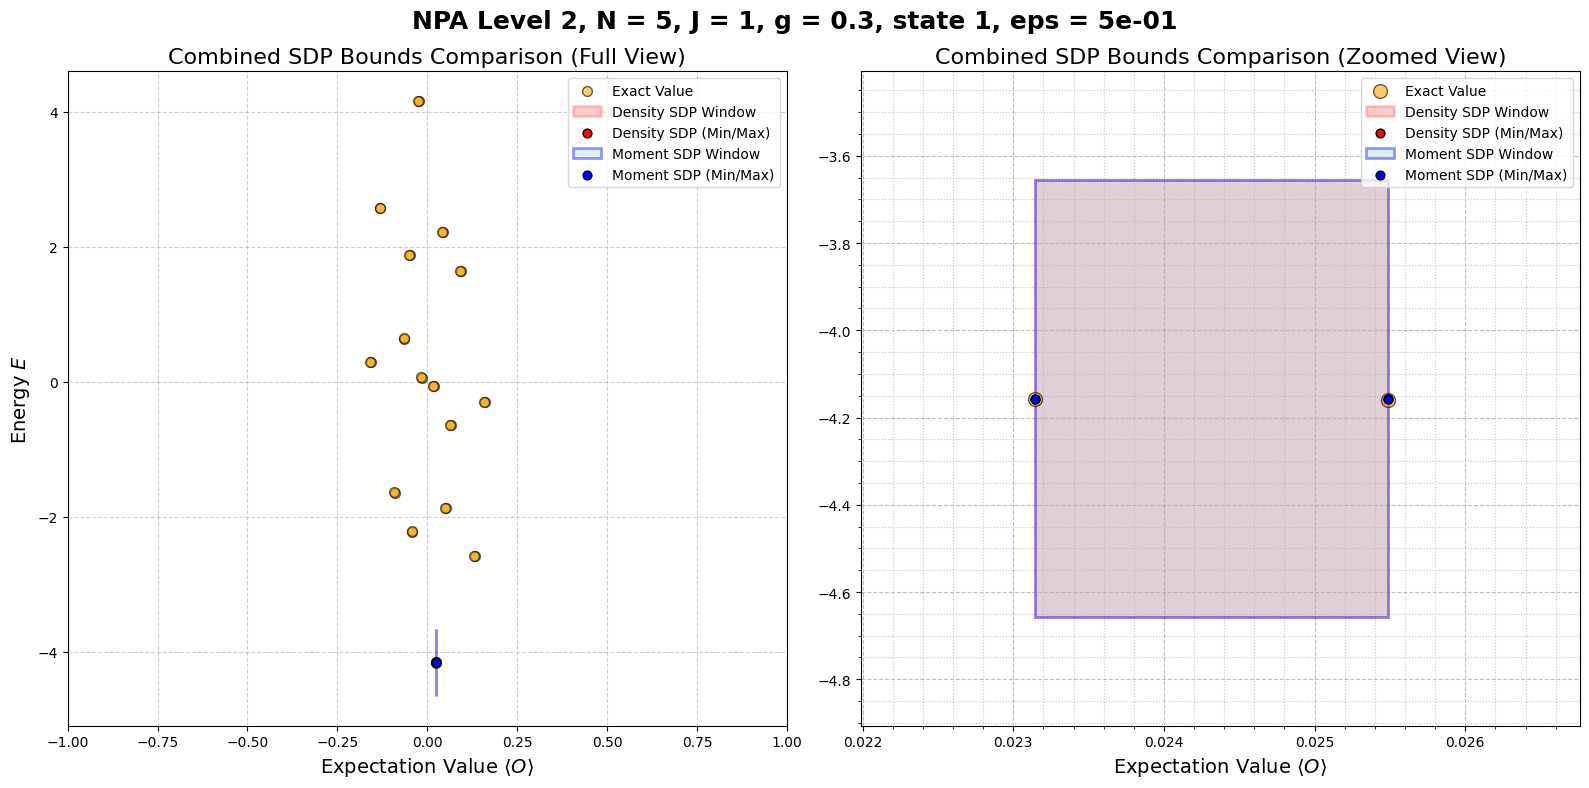

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 19.7142 seconds
Solving moment SDP max...
Elapsed time: 21.3828 seconds
Delta min bound density matrix: -2.75414e-09
Delta max bound density matrix: 0.00234225
Delta min bound moment matrix: -4.48629e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.02314492210153621 0.02314492481081727
The max bound density/moment 0.025487177558114193 0.025487176738565764
Min bound difference: 2.7092810633844167e-09
Max bound difference: 8.195484291206867e-10
Density matrix bound width: 2.342255e-03
Moment matrix bound width: 2.342252e-03


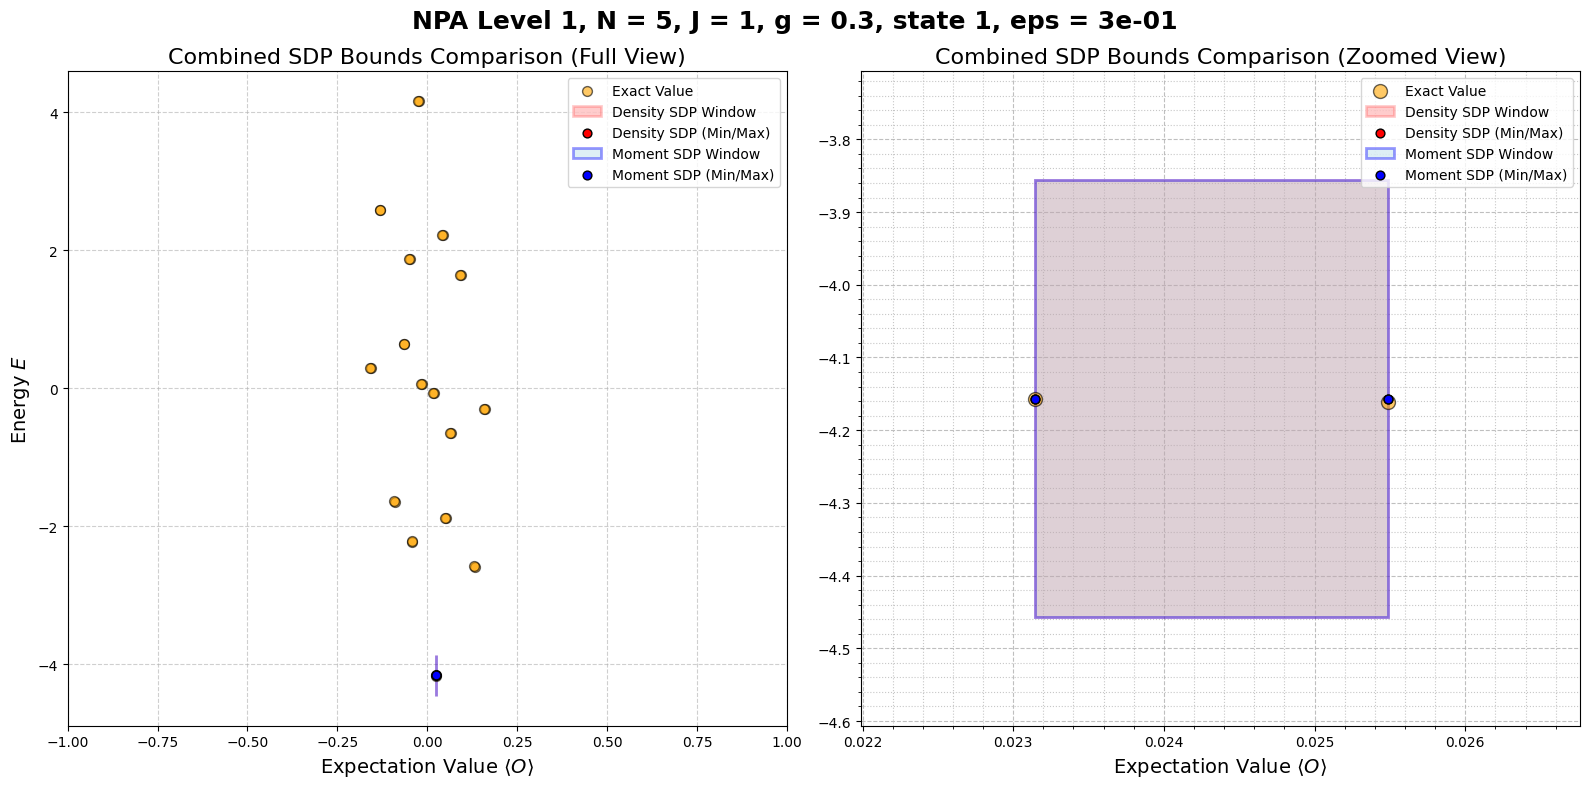

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 19.2978 seconds
Solving moment SDP max...
Elapsed time: 21.2712 seconds
Delta min bound density matrix: -2.75414e-09
Delta max bound density matrix: 0.00234225
Delta min bound moment matrix: -4.48629e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.02314492210153621 0.02314492481081727
The max bound density/moment 0.025487177558114193 0.025487176738565764
Min bound difference: 2.7092810633844167e-09
Max bound difference: 8.195484291206867e-10
Density matrix bound width: 2.342255e-03
Moment matrix bound width: 2.342252e-03


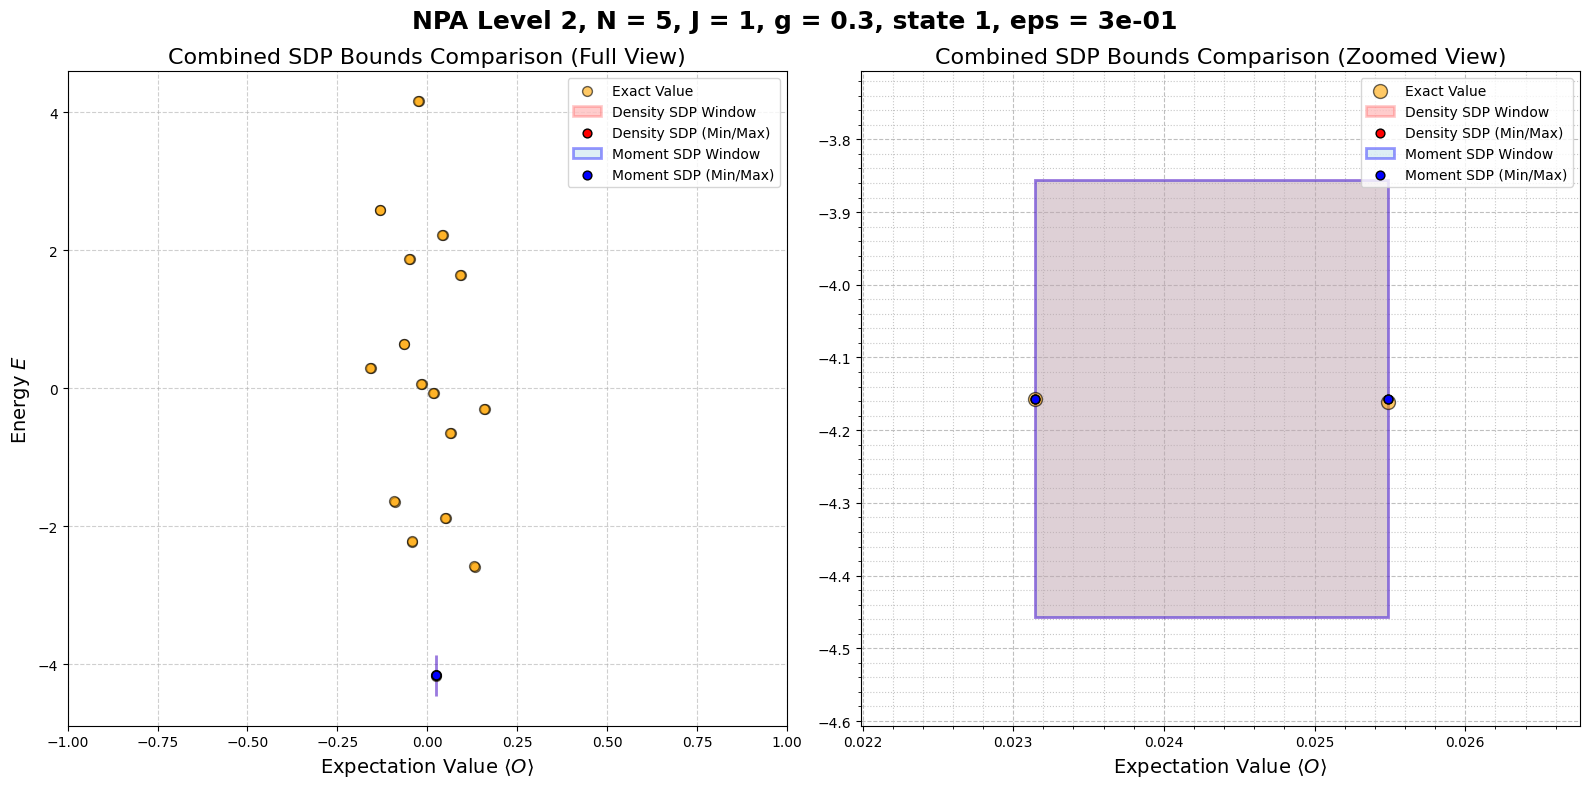

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.4551 seconds
Solving moment SDP max...
Elapsed time: 19.7927 seconds
Delta min bound density matrix: -7.33843e-08
Delta max bound density matrix: 0.00234225
Delta min bound moment matrix: -8.77239e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144851471334882 0.023144924767956276
The max bound density/moment 0.025487176650483473 0.025487176578320565
Min bound difference: 7.329662139385351e-08
Max bound difference: 7.216290759393118e-11
Density matrix bound width: 2.342325e-03
Moment matrix bound width: 2.342252e-03


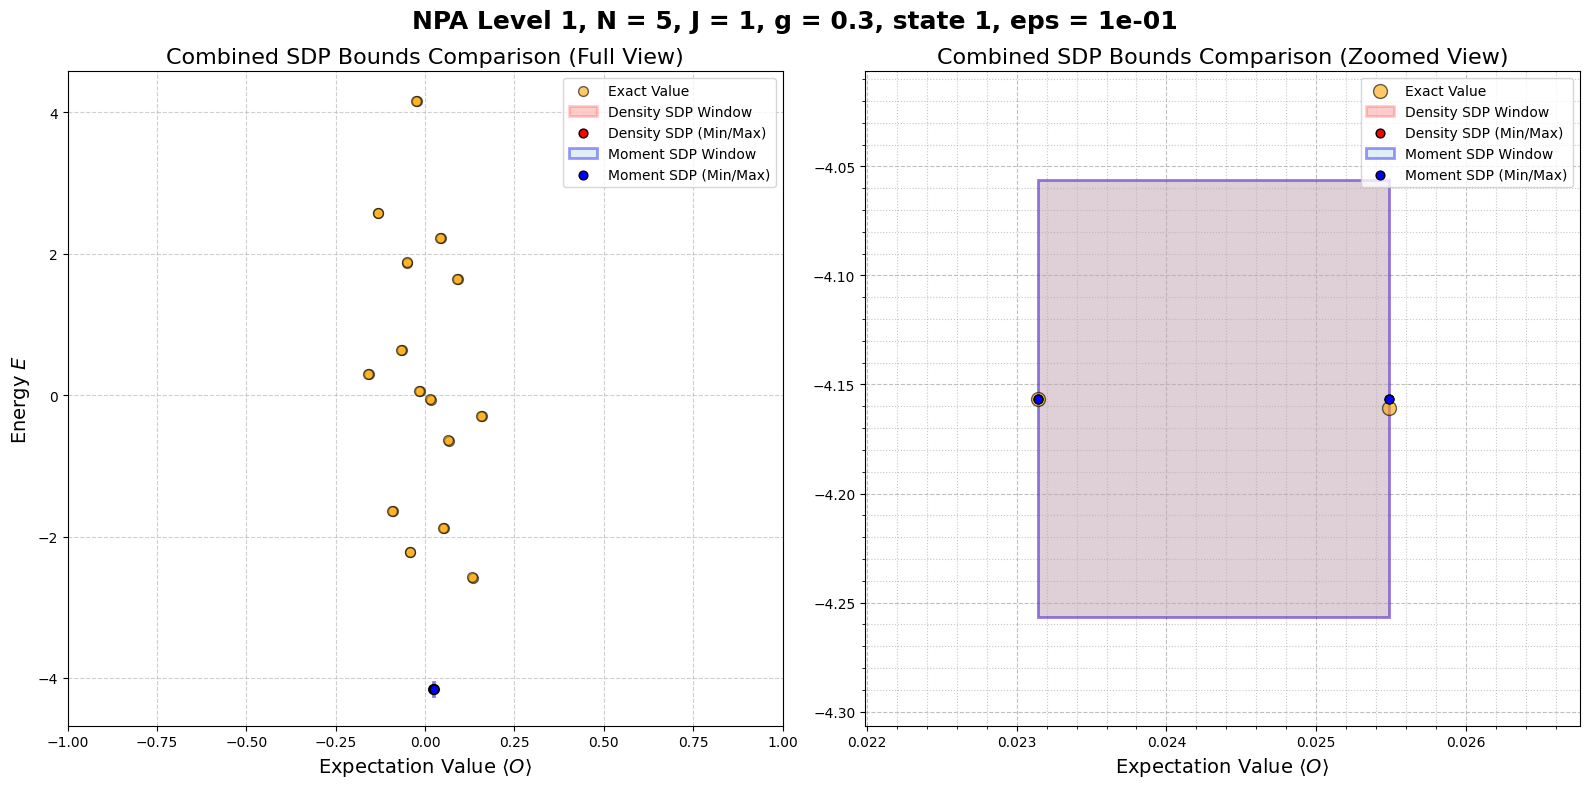

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.6125 seconds
Solving moment SDP max...
Elapsed time: 19.7140 seconds
Delta min bound density matrix: -7.33843e-08
Delta max bound density matrix: 0.00234225
Delta min bound moment matrix: -8.77239e-11
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144851471334882 0.023144924767956276
The max bound density/moment 0.025487176650483473 0.025487176578320565
Min bound difference: 7.329662139385351e-08
Max bound difference: 7.216290759393118e-11
Density matrix bound width: 2.342325e-03
Moment matrix bound width: 2.342252e-03


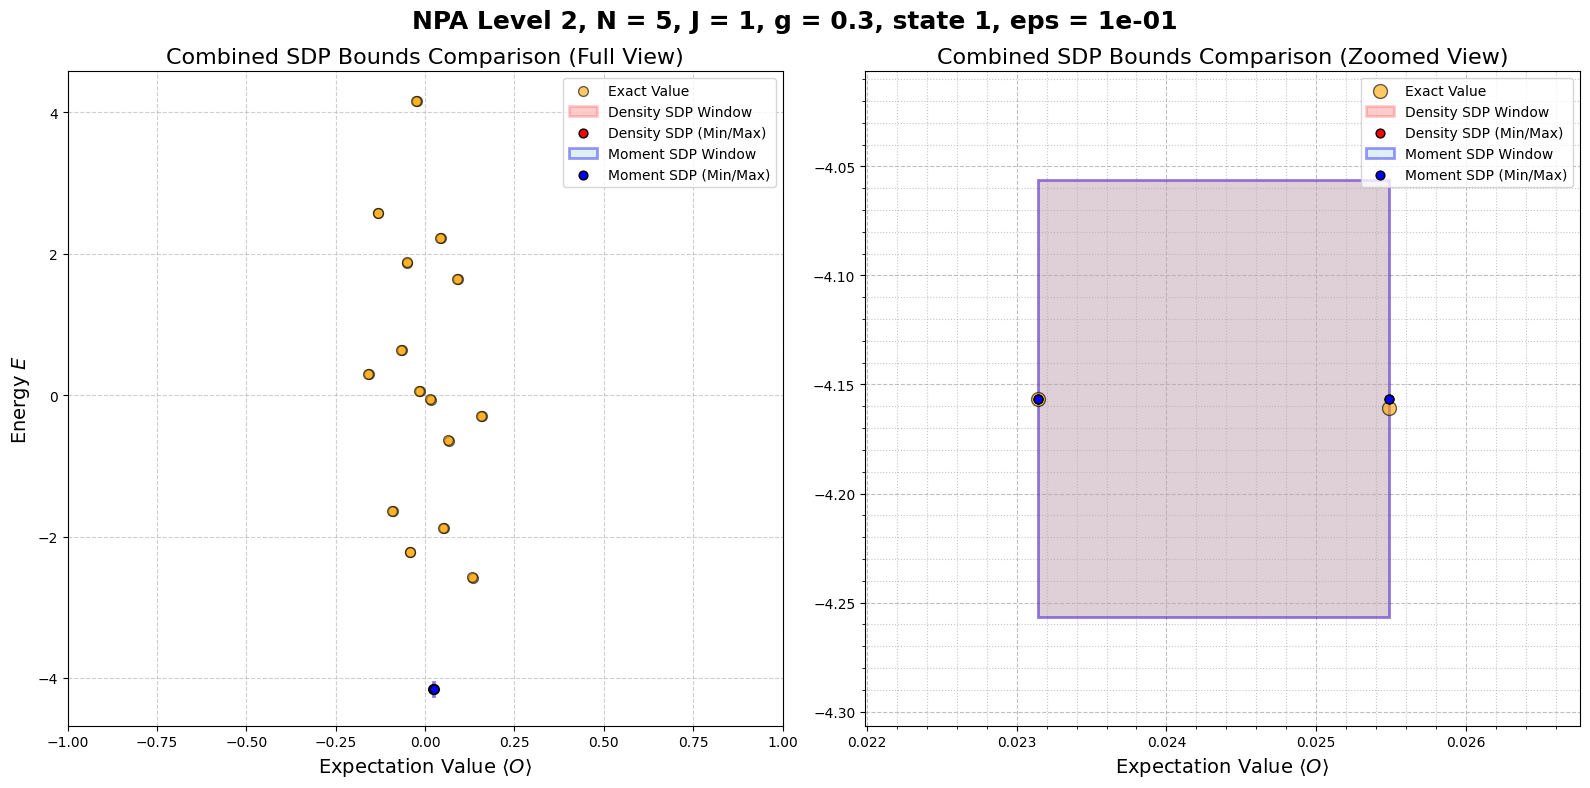

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.5702 seconds
Solving moment SDP max...
Elapsed time: 20.0587 seconds
Delta min bound density matrix: -3.25473e-09
Delta max bound density matrix: 0.00234234
Delta min bound moment matrix: -1.07739e-12
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144921600947943 0.023144924854602813
The max bound density/moment 0.02548726529896589 0.025487176754218202
Min bound difference: 3.2536548698336443e-09
Max bound difference: 8.854474768671405e-08
Density matrix bound width: 2.342344e-03
Moment matrix bound width: 2.342252e-03


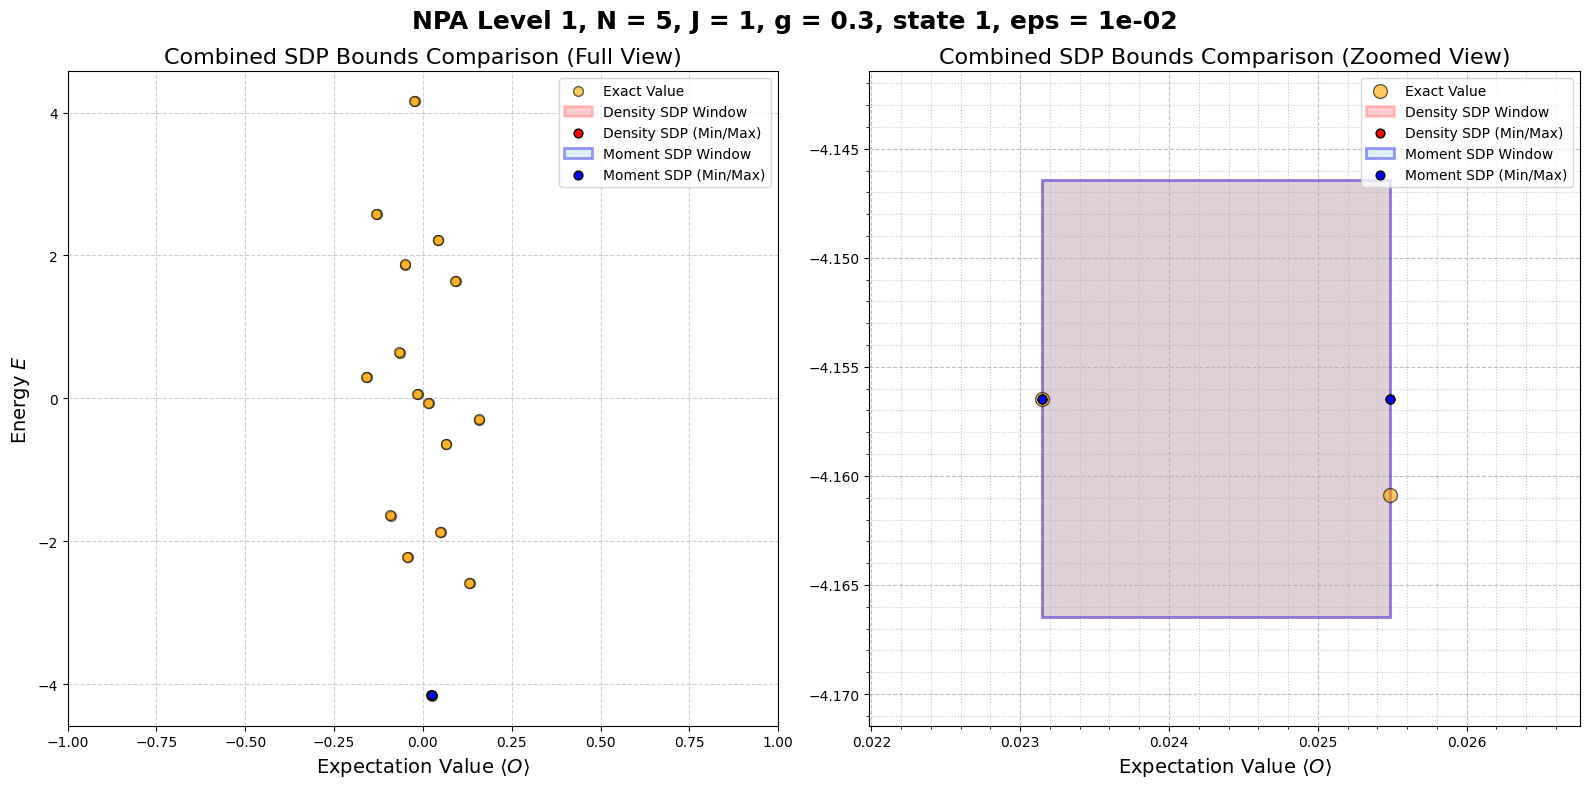

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.5717 seconds
Solving moment SDP max...
Elapsed time: 18.9624 seconds
Delta min bound density matrix: -3.25473e-09
Delta max bound density matrix: 0.00234234
Delta min bound moment matrix: -1.07739e-12
Delta max bound moment matrix: 0.00234225
The min bound density/moment 0.023144921600947943 0.023144924854602813
The max bound density/moment 0.02548726529896589 0.025487176754218202
Min bound difference: 3.2536548698336443e-09
Max bound difference: 8.854474768671405e-08
Density matrix bound width: 2.342344e-03
Moment matrix bound width: 2.342252e-03


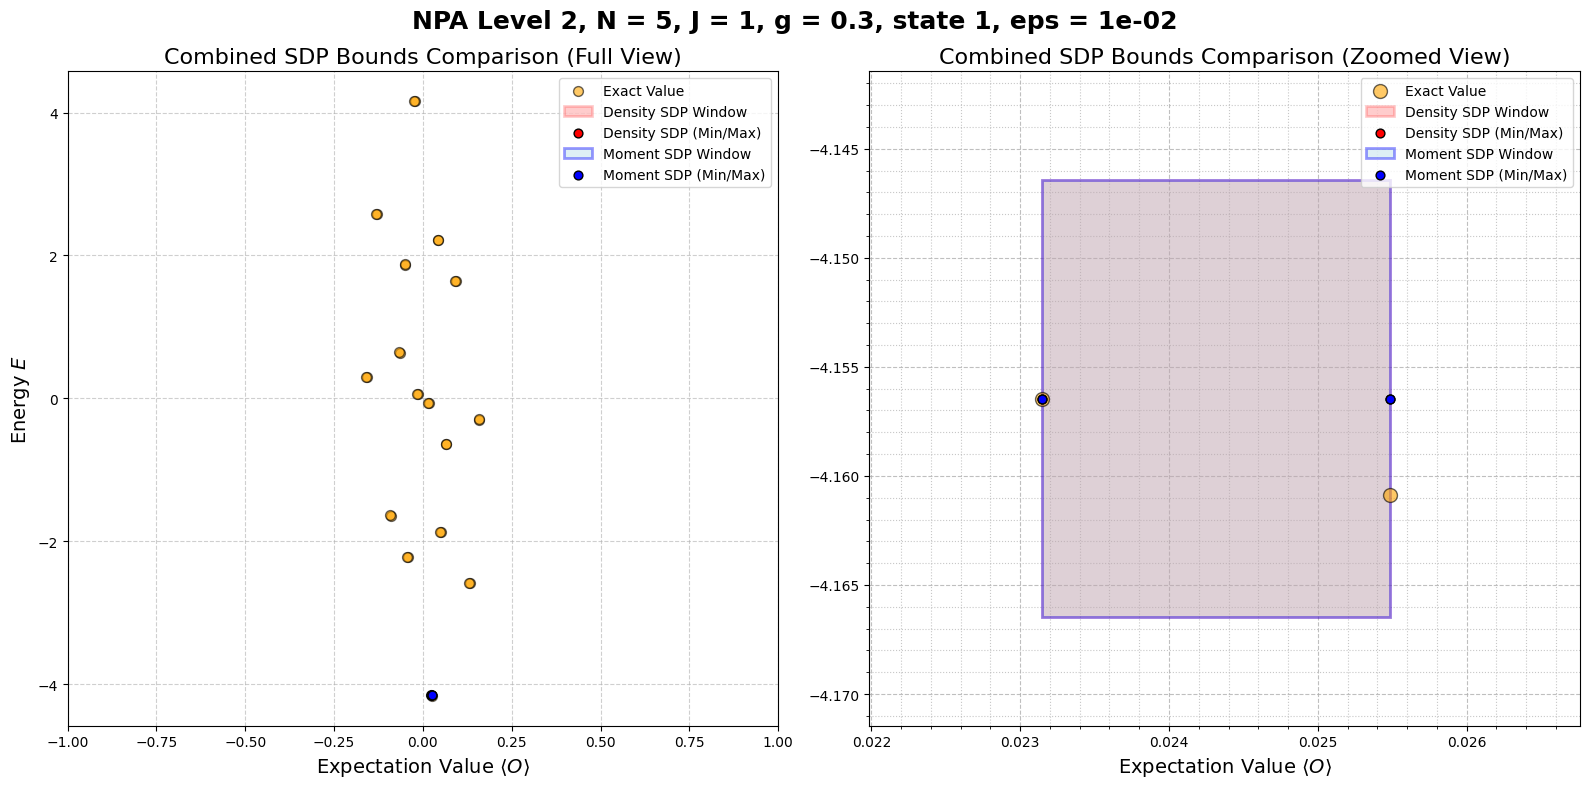

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.3707 seconds
Solving moment SDP max...
Elapsed time: 21.3843 seconds
Delta min bound density matrix: -1.94392e-07
Delta max bound density matrix: 6.5052e-08
Delta min bound moment matrix: -1.41453e-10
Delta max bound moment matrix: 1.90064e-09
The min bound density/moment 0.023144730463848823 0.023144924714227036
The max bound density/moment 0.023144989907649238 0.0231449267563161
Min bound difference: 1.942503782131899e-07
Max bound difference: 6.315133313852805e-08
Density matrix bound width: 2.594438e-07
Moment matrix bound width: 2.042089e-09


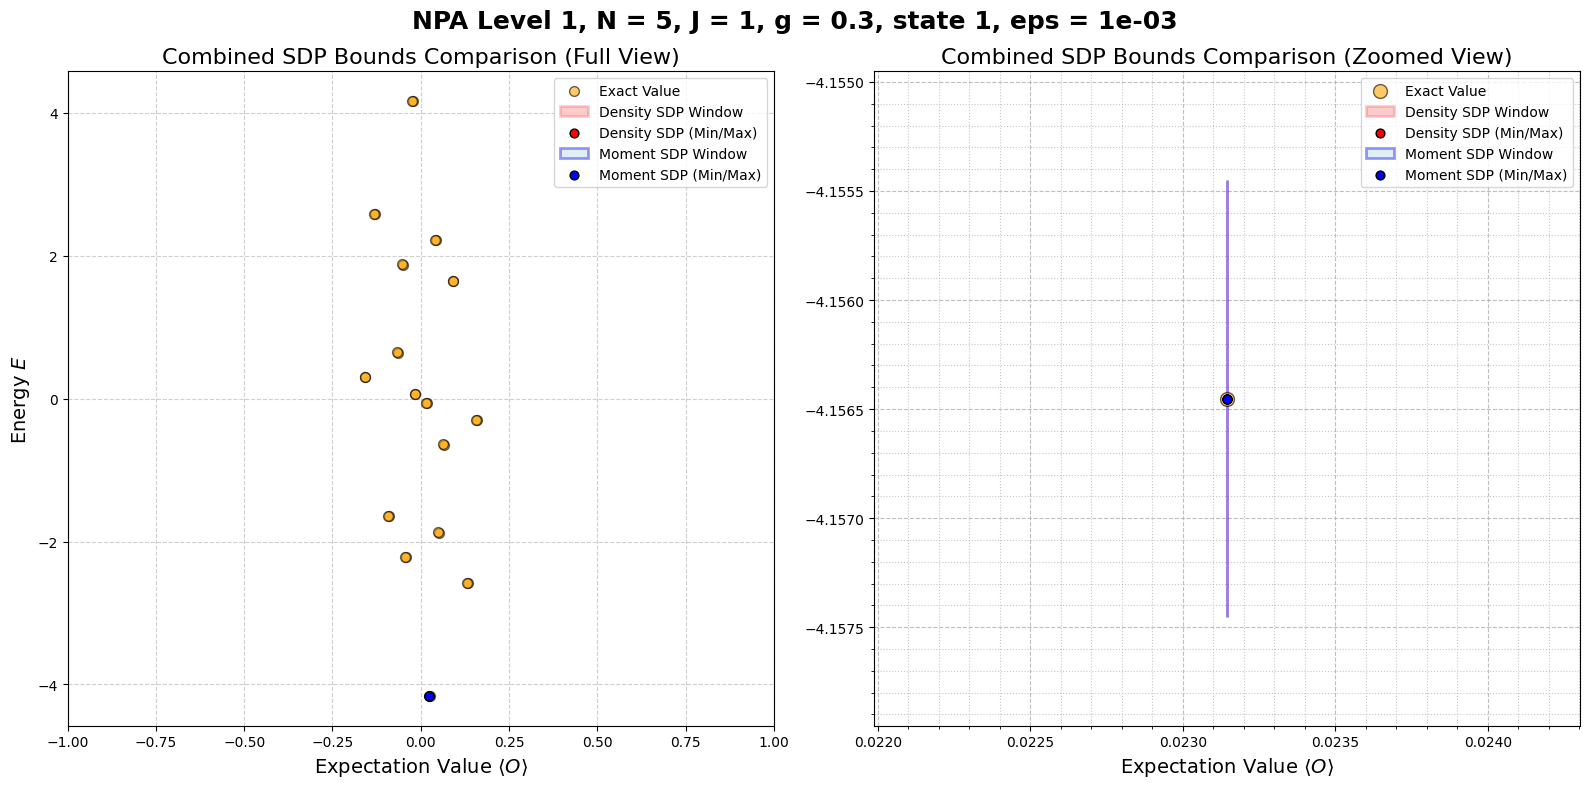

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 19.8912 seconds
Solving moment SDP max...
Elapsed time: 22.3006 seconds
Delta min bound density matrix: -1.94392e-07
Delta max bound density matrix: 6.5052e-08
Delta min bound moment matrix: -1.41453e-10
Delta max bound moment matrix: 1.90064e-09
The min bound density/moment 0.023144730463848823 0.023144924714227036
The max bound density/moment 0.023144989907649238 0.0231449267563161
Min bound difference: 1.942503782131899e-07
Max bound difference: 6.315133313852805e-08
Density matrix bound width: 2.594438e-07
Moment matrix bound width: 2.042089e-09


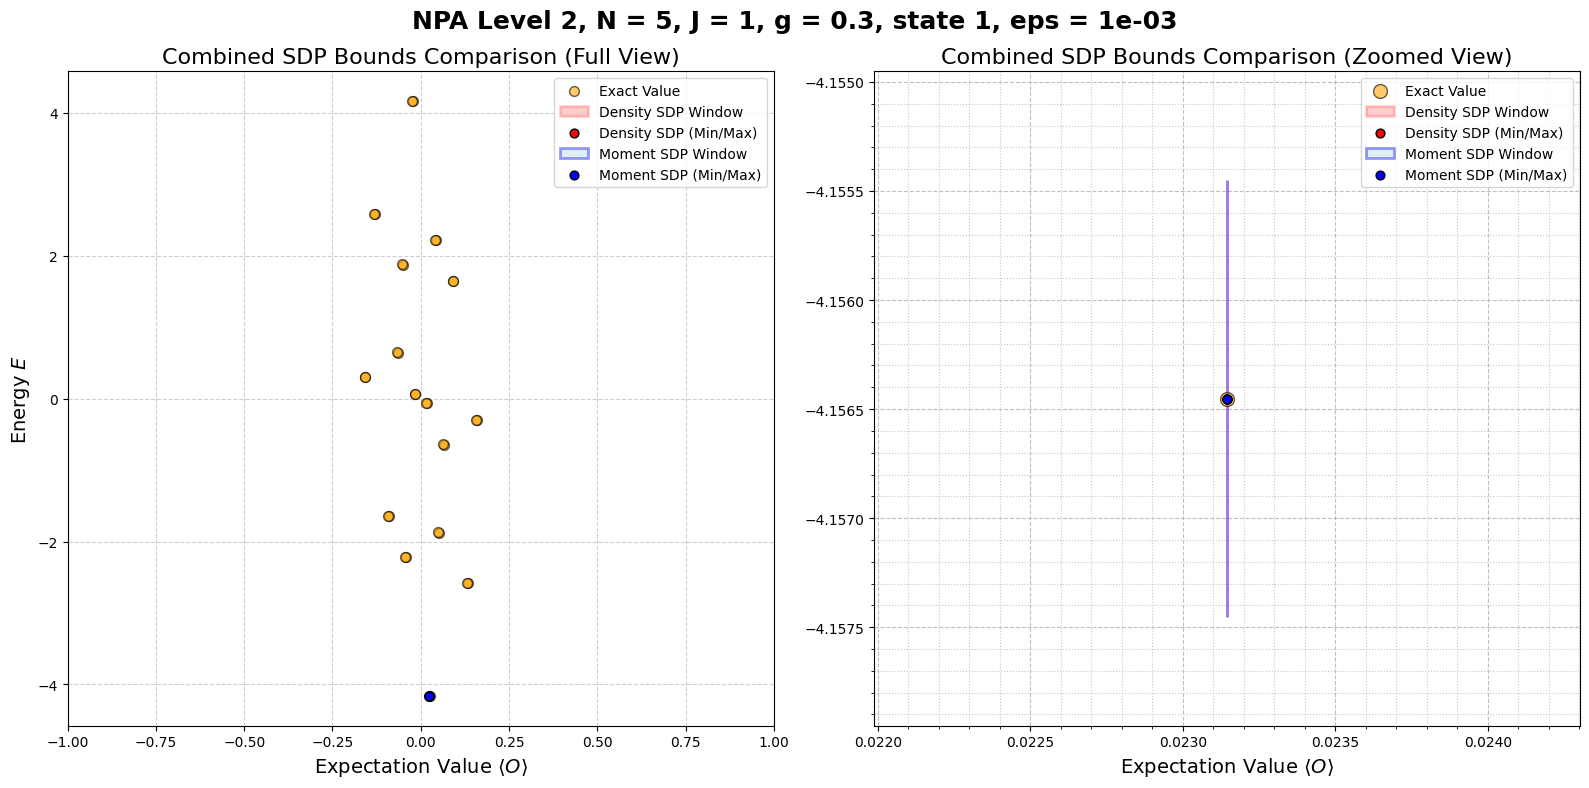

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 20.8615 seconds
Solving moment SDP max...
Elapsed time: 21.1894 seconds
Delta min bound density matrix: -1.3054e-08
Delta max bound density matrix: 6.90284e-11
Delta min bound moment matrix: -2.14178e-10
Delta max bound moment matrix: 9.10029e-10
The min bound density/moment 0.02314491180172676 0.023144924641501752
The max bound density/moment 0.02314492492470857 0.023144925765709277
Min bound difference: 1.2839774993222974e-08
Max bound difference: 8.410007065751124e-10
Density matrix bound width: 1.312298e-08
Moment matrix bound width: 1.124208e-09


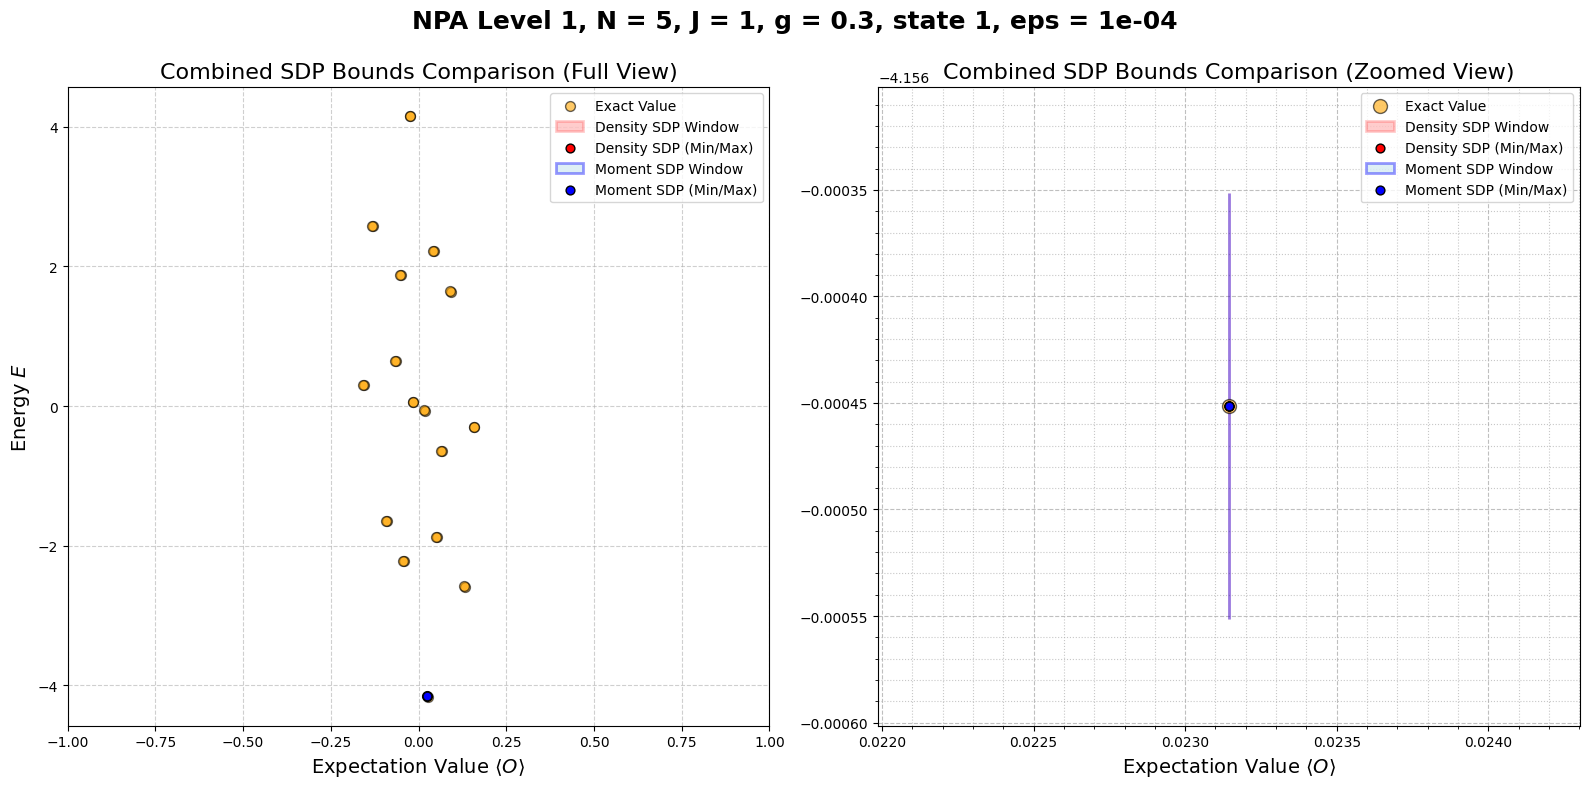

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 21.8476 seconds
Solving moment SDP max...
Elapsed time: 20.8225 seconds
Delta min bound density matrix: -1.3054e-08
Delta max bound density matrix: 6.90284e-11
Delta min bound moment matrix: -2.14178e-10
Delta max bound moment matrix: 9.10029e-10
The min bound density/moment 0.02314491180172676 0.023144924641501752
The max bound density/moment 0.02314492492470857 0.023144925765709277
Min bound difference: 1.2839774993222974e-08
Max bound difference: 8.410007065751124e-10
Density matrix bound width: 1.312298e-08
Moment matrix bound width: 1.124208e-09


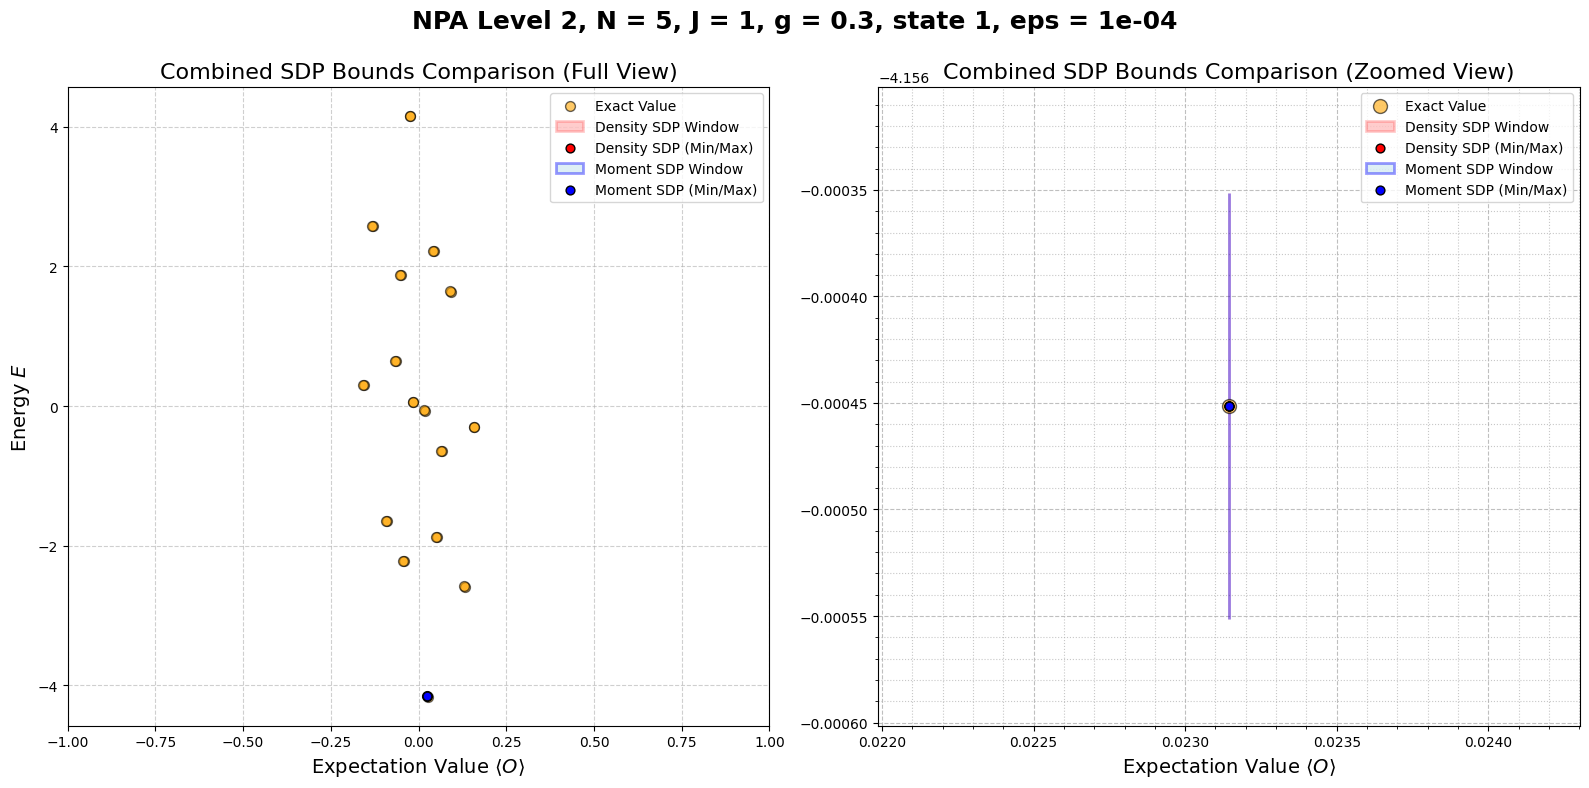

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 22.6264 seconds
Solving moment SDP max...
Elapsed time: 21.3436 seconds
Delta min bound density matrix: -4.20897e-11
Delta max bound density matrix: 1.74227e-07
Delta min bound moment matrix: -4.30085e-10
Delta max bound moment matrix: 1.0193e-09
The min bound density/moment 0.023144924813590484 0.023144924425594952
The max bound density/moment 0.023145099082634873 0.02314492587498255
Min bound difference: 3.8799553153667787e-10
Max bound difference: 1.7320765232503588e-07
Density matrix bound width: 1.742690e-07
Moment matrix bound width: 1.449388e-09


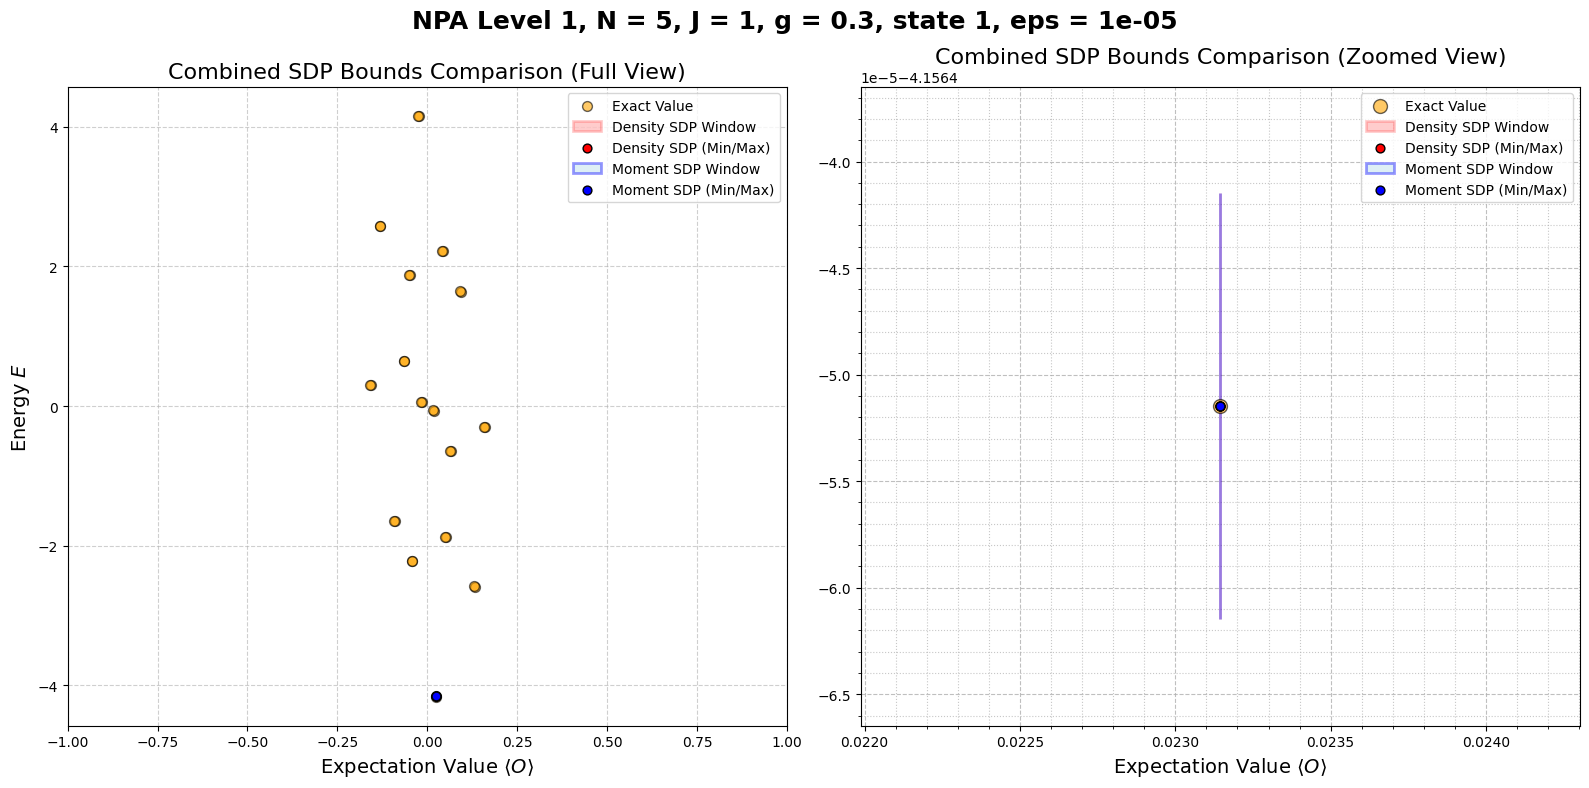

Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 22.6079 seconds
Solving moment SDP max...
Elapsed time: 20.9846 seconds
Delta min bound density matrix: -4.20897e-11
Delta max bound density matrix: 1.74227e-07
Delta min bound moment matrix: -4.30085e-10
Delta max bound moment matrix: 1.0193e-09
The min bound density/moment 0.023144924813590484 0.023144924425594952
The max bound density/moment 0.023145099082634873 0.02314492587498255
Min bound difference: 3.8799553153667787e-10
Max bound difference: 1.7320765232503588e-07
Density matrix bound width: 1.742690e-07
Moment matrix bound width: 1.449388e-09


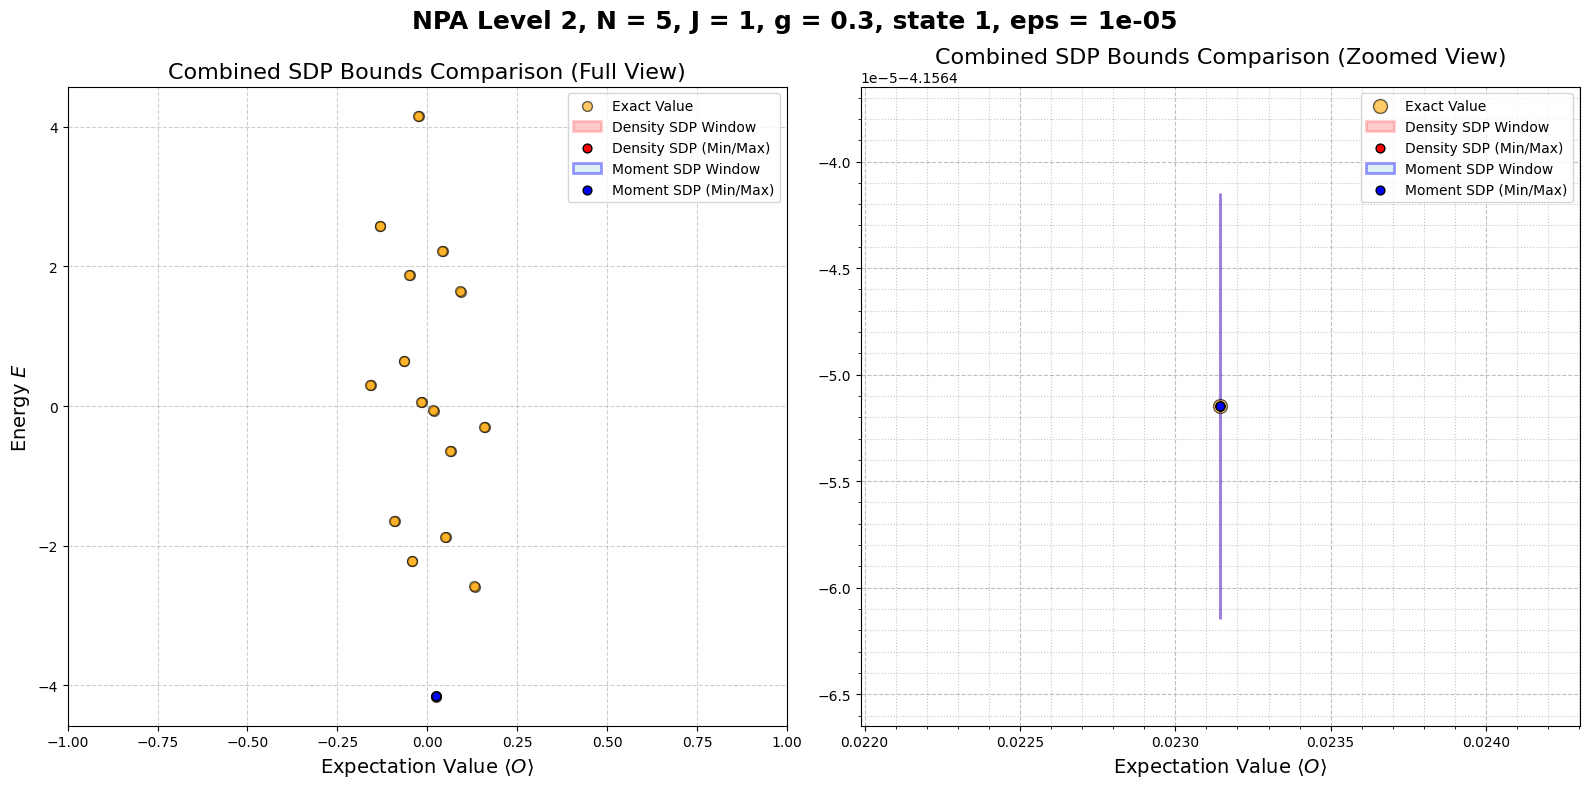

In [25]:
from Moment import *
Ns = [5]

Js = [1]
gs = [0.3]
npa_levels = [1,2]
indexes = range(0,N//2)
rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
H = build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)
basis = NPA(npa_level, N, _, True)
eps_list = [0.5, 0.3, 0.1, 1e-2, 1e-3, 1e-4, 1e-5]

#exact diagonalization

eigenvalues, eigenvectors = load_eigen(f"eigenvalues{N}.npz", H)
expectation_values = []

expectation_values = get_expectation(N, N//2, rand_op1, eigenvalues, eigenvectors)

#density matrix sdp

energy = eigenvalues[index]

for N, J, g, index, eps, npa_level in product(Ns, Js, gs, indexes, eps_list, npa_levels):
    
    print("Solving density matrix SDP min...")
    min_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, True).value
    
    print("Solving density matrix SDP max...")
    max_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, False).value
    
    # moment sdp
    
    print("Solving moment SDP min...")
    
    start = time.time()
    min_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, True)
    end = time.time()
    print(f"Elapsed time: {end - start:.4f} seconds")
    
    print("Solving moment SDP max...")
    
    start = time.time()
    max_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, False)
    end = time.time()
    print(f"Elapsed time: {end - start:.4f} seconds")
    
    min_delta =  min_sdp_moment.value - expectation_values[index]
    max_delta = max_sdp_moment.value - expectation_values[index]
    
    print(f"Delta min bound density matrix: {min_sdp_density_mat - expectation_values[index]:.6}")
    print(f"Delta max bound density matrix: {max_sdp_density_mat - expectation_values[index]:.6}")
    
    print(f"Delta min bound moment matrix: {min_delta:.6}")
    print(f"Delta max bound moment matrix: {max_delta:.6}")
    
    print("The min bound density/moment",min_sdp_density_mat, min_sdp_moment.value)
    print("The max bound density/moment",max_sdp_density_mat, max_sdp_moment.value)
    print(f"Min bound difference: {np.abs(min_sdp_density_mat - min_sdp_moment.value)}")
    print(f"Max bound difference: {np.abs(max_sdp_moment.value - max_sdp_density_mat)}")
    # print("Exact expectation value",expectation_values[index])
    # print("Exact expectation value",expectation_values[index - 1])
    
    print(f"Density matrix bound width: {max_sdp_density_mat - min_sdp_density_mat:.6e}")
    print(f"Moment matrix bound width: {max_sdp_moment.value - min_sdp_moment.value:.6e}")
    
    
    plot_name = f'NPA Level {npa_level}, N = {N}, J = {J}, g = {g}, state {index}, eps = {eps:.0e}'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(plot_name, fontsize=18, fontweight='bold')
    
    ax1.scatter(expectation_values, eigenvalues, 
                color='orange', alpha=0.6, edgecolors='k', s=50, zorder=3, label='Exact Value')
    
    rect1_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                             max_sdp_density_mat - min_sdp_density_mat, 
                             2 * eps, 
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
    ax1.add_patch(rect1_dens)
    
    ax1.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
                color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')
    
    rect1_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                             max_sdp_moment.value - min_sdp_moment.value, 
                             2 * eps, 
                             linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
    ax1.add_patch(rect1_mom)
    
    ax1.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
                color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')
    
    ax1.set_xlim(-1, 1)
    ax1.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
    ax1.set_ylabel('Energy $E$', fontsize=14)
    ax1.set_title('Combined SDP Bounds Comparison (Full View)', fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax1.legend(loc='upper right')
    
    
    ax2.scatter(expectation_values, eigenvalues, 
                color='orange', alpha=0.6, edgecolors='k', s=100, zorder=3, label='Exact Value')
    
    rect2_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                             max_sdp_density_mat - min_sdp_density_mat, 
                             2 * eps, 
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
    ax2.add_patch(rect2_dens)
    
    ax2.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
                color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')
    
    rect2_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                             max_sdp_moment.value - min_sdp_moment.value, 
                             2 * eps, 
                             linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
    ax2.add_patch(rect2_mom)
    
    ax2.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
                color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')
    
    zoom_min = min(min_sdp_density_mat, min_sdp_moment.value)
    zoom_max = max(max_sdp_density_mat, max_sdp_moment.value)
    
    ax2.set_xlim(zoom_min - 0.05 * np.abs(zoom_min), zoom_max + 0.05 * np.abs(zoom_max))
    ax2.set_ylim(energy - eps - 0.5 * (eps), energy + eps + 0.5 * (eps))
    
    ax2.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
    ax2.set_title('Combined SDP Bounds Comparison (Zoomed View)', fontsize=16)
    
    ax2.minorticks_on()
    ax2.grid(True, which='major', linestyle='--', alpha=0.8, zorder=0)
    ax2.grid(True, which='minor', linestyle=':', alpha=0.7, zorder=0)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
basis = NPA(1, 3, _, True)
print(basis)
# basis = generate_neighbour_monomials(NPA(npa_level, N, _, True), 1)
print(len(basis))
print(len(NPA(npa_level, N, _, True)))
basis2 = generate_neighbour_monomials(basis, 1)
basis2 = basis + basis2
print(basis2)
print(len(basis2))

[(I, [(0, 0, 0)], 1.0), (X, [(1, 0, 0)], 1.0), (Y, [(1, 0, 0)], 1.0), (Z, [(1, 0, 0)], 1.0), (X, [(2, 0, 0)], 1.0), (Y, [(2, 0, 0)], 1.0), (Z, [(2, 0, 0)], 1.0), (X, [(3, 0, 0)], 1.0), (Y, [(3, 0, 0)], 1.0), (Z, [(3, 0, 0)], 1.0)]
10
16
[(I, [(0, 0, 0)], 1.0), (X, [(1, 0, 0)], 1.0), (Y, [(1, 0, 0)], 1.0), (Z, [(1, 0, 0)], 1.0), (X, [(2, 0, 0)], 1.0), (Y, [(2, 0, 0)], 1.0), (Z, [(2, 0, 0)], 1.0), (X, [(3, 0, 0)], 1.0), (Y, [(3, 0, 0)], 1.0), (Z, [(3, 0, 0)], 1.0), (XX, [(1, 0, 0), (2, 0, 0)], 1.0), (XY, [(1, 0, 0), (2, 0, 0)], 1.0), (XZ, [(1, 0, 0), (2, 0, 0)], 1.0), (YX, [(1, 0, 0), (2, 0, 0)], 1.0), (YY, [(1, 0, 0), (2, 0, 0)], 1.0), (YZ, [(1, 0, 0), (2, 0, 0)], 1.0), (ZX, [(1, 0, 0), (2, 0, 0)], 1.0), (ZY, [(1, 0, 0), (2, 0, 0)], 1.0), (ZZ, [(1, 0, 0), (2, 0, 0)], 1.0), (XX, [(2, 0, 0), (3, 0, 0)], 1.0), (XY, [(2, 0, 0), (3, 0, 0)], 1.0), (XZ, [(2, 0, 0), (3, 0, 0)], 1.0), (YX, [(2, 0, 0), (3, 0, 0)], 1.0), (YY, [(2, 0, 0), (3, 0, 0)], 1.0), (YZ, [(2, 0, 0), (3, 0, 0)], 1.0), (ZX, [(

19
64
Solving density matrix SDP min...
Solving density matrix SDP max...
Solving moment SDP min...
Elapsed time: 31.9785 seconds
Solving moment SDP max...
Elapsed time: 31.6086 seconds
Delta min bound density matrix: -5.96915e-10
Delta max bound density matrix: 3.93056e-07
Delta min bound moment matrix: -0.832637
Delta max bound moment matrix: 0.159339
The min bound density/moment 0.31209746745258915 -0.5205399072073447
The max bound density/moment 0.31209786110519544 0.4714368433042539
Min bound difference: 0.8326373746599338
Max bound difference: 0.15933898219905845
Density matrix bound width: 3.936526e-07
Moment matrix bound width: 9.919768e-01


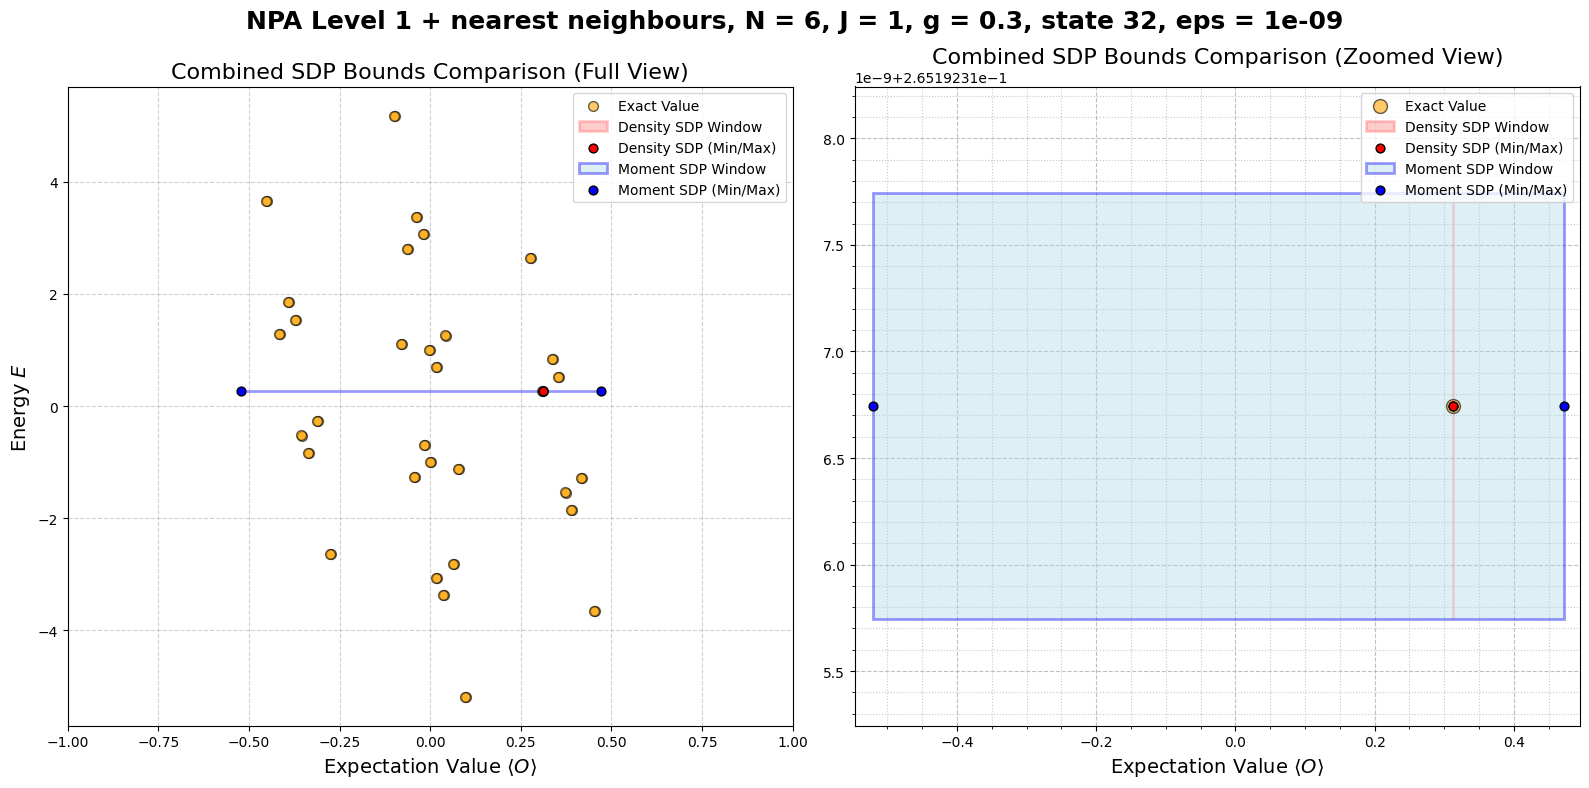

In [35]:
from Moment import *
Ns = range(6,7)

Js = [1]
gs = [0.3]
npa_levels = [1]



eps_list = [ 1e-9]

#exact diagonalization



for N, J, g, eps, npa_level in product(Ns, Js, gs, eps_list, npa_levels):
    index = 2**(N-1)
    rand_op1, symbolic_op = random_pm1_hermitian((N//2 + 1,0,0))
    basis = NPA(npa_level, N, _, True)
    print(len(basis))
    basis = basis + generate_neighbour_monomials(basis, 1)
    print(len(basis))
    H = build_hamiltonian(N, J, 0, g, 0, 0, 0, 0)

    eigenvalues, eigenvectors = load_eigen(f"eigenvalues{N}.npz", H)
    expectation_values = []
    
    expectation_values = get_expectation(N, N//2, rand_op1, eigenvalues, eigenvectors)
    
    #density matrix sdp
    
    energy = eigenvalues[index]
    
    print("Solving density matrix SDP min...")
    min_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, True).value
    
    print("Solving density matrix SDP max...")
    max_sdp_density_mat = density_matrix_sdp(N, H, energy, eps, N//2, rand_op1, False).value
    
    # moment sdp
    
    print("Solving moment SDP min...")
    
    start = time.time()
    min_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, True)
    end = time.time()
    print(f"Elapsed time: {end - start:.4f} seconds")
    
    print("Solving moment SDP max...")
    
    start = time.time()
    max_sdp_moment = moment_sdp(N, get_symbolic_hamiltonian(N, J, g), basis, symbolic_op, energy, eps, False)
    end = time.time()
    print(f"Elapsed time: {end - start:.4f} seconds")
    
    min_delta =  min_sdp_moment.value - expectation_values[index]
    max_delta = max_sdp_moment.value - expectation_values[index]
    
    print(f"Delta min bound density matrix: {min_sdp_density_mat - expectation_values[index]:.6}")
    print(f"Delta max bound density matrix: {max_sdp_density_mat - expectation_values[index]:.6}")
    
    print(f"Delta min bound moment matrix: {min_delta:.6}")
    print(f"Delta max bound moment matrix: {max_delta:.6}")
    
    print("The min bound density/moment",min_sdp_density_mat, min_sdp_moment.value)
    print("The max bound density/moment",max_sdp_density_mat, max_sdp_moment.value)
    print(f"Min bound difference: {np.abs(min_sdp_density_mat - min_sdp_moment.value)}")
    print(f"Max bound difference: {np.abs(max_sdp_moment.value - max_sdp_density_mat)}")
    # print("Exact expectation value",expectation_values[index])
    # print("Exact expectation value",expectation_values[index - 1])
    
    print(f"Density matrix bound width: {max_sdp_density_mat - min_sdp_density_mat:.6e}")
    print(f"Moment matrix bound width: {max_sdp_moment.value - min_sdp_moment.value:.6e}")
    
    
    plot_name = f'NPA Level {npa_level} + nearest neighbours, N = {N}, J = {J}, g = {g}, state {index}, eps = {eps:.0e}'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(plot_name, fontsize=18, fontweight='bold')
    
    ax1.scatter(expectation_values, eigenvalues, 
                color='orange', alpha=0.6, edgecolors='k', s=50, zorder=3, label='Exact Value')
    
    rect1_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                             max_sdp_density_mat - min_sdp_density_mat, 
                             2 * eps, 
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
    ax1.add_patch(rect1_dens)
    
    ax1.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
                color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')
    
    rect1_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                             max_sdp_moment.value - min_sdp_moment.value, 
                             2 * eps, 
                             linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
    ax1.add_patch(rect1_mom)
    
    ax1.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
                color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')
    
    ax1.set_xlim(-1, 1)
    ax1.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
    ax1.set_ylabel('Energy $E$', fontsize=14)
    ax1.set_title('Combined SDP Bounds Comparison (Full View)', fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax1.legend(loc='upper right')
    
    
    ax2.scatter(expectation_values, eigenvalues, 
                color='orange', alpha=0.6, edgecolors='k', s=100, zorder=3, label='Exact Value')
    
    rect2_dens = patches.Rectangle((min_sdp_density_mat, energy - eps), 
                             max_sdp_density_mat - min_sdp_density_mat, 
                             2 * eps, 
                             linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, zorder=2, label='Density SDP Window')
    ax2.add_patch(rect2_dens)
    
    ax2.scatter([min_sdp_density_mat, max_sdp_density_mat], [energy, energy], 
                color='red', marker='o', s=40, edgecolors='k', zorder=4, label='Density SDP (Min/Max)')
    
    rect2_mom = patches.Rectangle((min_sdp_moment.value, energy - eps), 
                             max_sdp_moment.value - min_sdp_moment.value, 
                             2 * eps, 
                             linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.4, zorder=2, label='Moment SDP Window')
    ax2.add_patch(rect2_mom)
    
    ax2.scatter([min_sdp_moment.value, max_sdp_moment.value], [energy, energy], 
                color='blue', marker='o', s=40, edgecolors='k', zorder=5, label='Moment SDP (Min/Max)')
    
    zoom_min = min(min_sdp_density_mat, min_sdp_moment.value)
    zoom_max = max(max_sdp_density_mat, max_sdp_moment.value)
    
    ax2.set_xlim(zoom_min - 0.05 * np.abs(zoom_min), zoom_max + 0.05 * np.abs(zoom_max))
    ax2.set_ylim(energy - eps - 0.5 * (eps), energy + eps + 0.5 * (eps))
    
    ax2.set_xlabel('Expectation Value $\\langle O \\rangle$', fontsize=14)
    ax2.set_title('Combined SDP Bounds Comparison (Zoomed View)', fontsize=16)
    
    ax2.minorticks_on()
    ax2.grid(True, which='major', linestyle='--', alpha=0.8, zorder=0)
    ax2.grid(True, which='minor', linestyle=':', alpha=0.7, zorder=0)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# 0.5393266919253318 -  0.48797458764537255

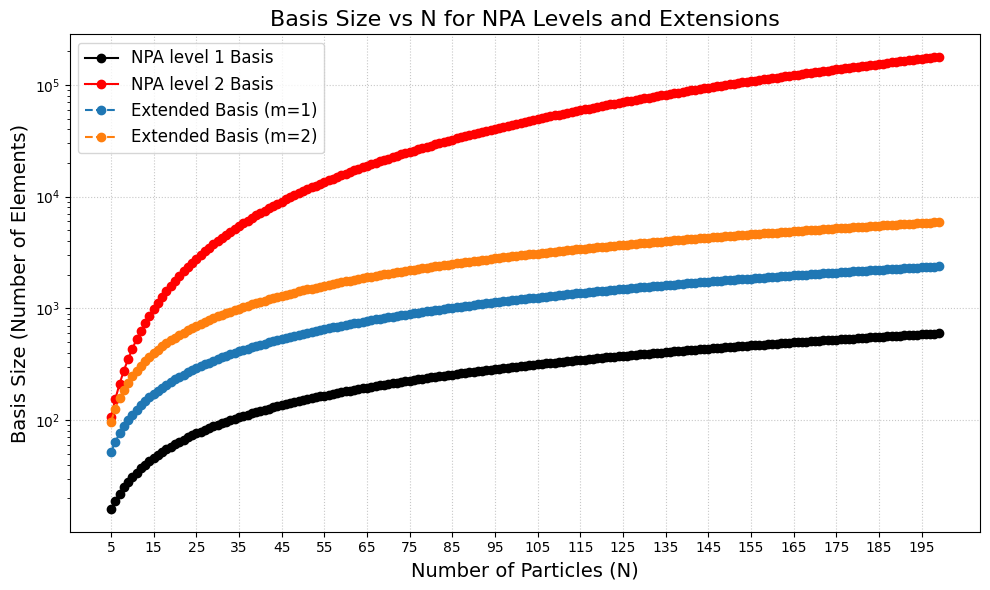

In [26]:
ms = [1, 2]
normal = []
NPA2 = []
extended = {m: [] for m in ms}
N_range = range(5, 200)

for i in N_range:
    base_basis = NPA(1, i, _, True)
    normal.append(len(base_basis))
    NPA2.append(len(NPA(2, i, _, True)))
    for m in ms:
        ext_basis = base_basis + generate_neighbour_monomials(base_basis, m)
        extended[m].append(len(ext_basis))

plt.figure(figsize=(10, 6))
plt.plot(N_range, normal, marker='o', linestyle='-', color='black', label='NPA level 1 Basis')
plt.plot(N_range, NPA2, marker='o', linestyle='-', color='red', label='NPA level 2 Basis')

for m in ms:
    plt.plot(N_range, extended[m], marker='o', linestyle='--', label=f'Extended Basis (m={m})')

plt.yscale('log')
plt.xlabel('Number of Particles (N)', fontsize=14)
plt.ylabel('Basis Size (Number of Elements)', fontsize=14)
plt.title('Basis Size vs N for NPA Levels and Extensions', fontsize=16)
plt.xticks(list(N_range)[::10])
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()